# 🎯 BadNets Backdoor Attack — Full Sweep & Defenses

**Attack:** BadNets (Gu et al., 2017) | **Model:** ResNet-18 (CIFAR-stem) | **Dataset:** CIFAR-10
**Locked Constants:** `SEED=2025` | `TARGET_CLASS=0` | `EPOCHS=68`

This notebook runs the full experimental pipeline for the BadNets Backdoor attack. It evaluates Attack Success Rate (ASR) alongside detection methods (Activation Clustering and STRIP) across main (1%/5%/10%) and sub-1% low-count poison sweeps.

### 📋 Notebook Structure & Cell Index

**Section A: Setup (Cells 1–6)**
* **Cells 1–5:** Establishes global constants, mounts Google Drive, clones the repository, and imports core model/metric utilities.
* **Cell 6:** Efficiently loads clean CIFAR-10 data directly from a Drive cache to avoid network overhead.

**Section B: Poison Cache (Cell 7)**
* **Cell 7:** Poisons the 10% union set using a prefix-slice method to lock in the 5% and 1% sets. Pool: non-target-class only (dirty-label convention, same as Blended).

**Section C: Per-Rate Training (Cells 8A, 8B, 8C)**
* **Cells 8A–8C:** Independently trains ResNet-18 models on the 1%, 5%, and 10% poison rates.

**Section D: Detection – Activation Caching & DR (Cells 9–10)**
* **Cell 9:** Extracts and caches penultimate-layer model activations on the poisoned training sets.
* **Cell 10:** Runs AC comparing PCA-2D and ICA-10D.

**Section E: Final Summary (Cell 11)**

**Section G: Sub-1% Poison-Count Sweep (Cells 12–13)**

**Section H: AC on Low-Count Models (Cells 14–15)**

**Section I: STRIP Detection (Cells 16–17)**

**Section K: Grad-CAM Pre-Defense Verification (Cell 18)**

---
## Section A — Setup (run once per session)

In [1]:
# ════════════════════════════════════════════════════════════════════════════
# Cell 1 — Reproducibility + Global Constants  [DO NOT MODIFY VALUES]
# ════════════════════════════════════════════════════════════════════════════
import torch, numpy as np, random, os
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from tqdm import tqdm
import pandas as pd

# ── Locked project-wide constants ──────────────────────────────────────────────
ATTACK_NAME  = 'BadNets'
SEED         = 2027   # DO NOT CHANGE
TARGET_CLASS = 0      # Airplane -- DO NOT CHANGE
EPOCHS       = 68     # optimized BadNets training -- DO NOT CHANGE
BATCH_SIZE   = 128
POISON_RATES = [0.01, 0.05, 0.10]   # 1%, 5%, 10%
TRIGGER_SIZE = 4      # 4x4 white patch in bottom-right corner

def set_seed(seed=SEED):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

set_seed(SEED)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

print('Using device:', DEVICE)
print(f'ATTACK={ATTACK_NAME} | SEED={SEED} | TARGET_CLASS={TARGET_CLASS} | '
      f'EPOCHS={EPOCHS} | BATCH_SIZE={BATCH_SIZE}')
print('Poison rates:', POISON_RATES)

Using device: cuda
ATTACK=BadNets | SEED=2027 | TARGET_CLASS=0 | EPOCHS=68 | BATCH_SIZE=128
Poison rates: [0.01, 0.05, 0.1]


In [2]:
# ════════════════════════════════════════════════════════════════════════════
# Cell 2 — Mount Drive + Clone Repo + Project Paths
# ════════════════════════════════════════════════════════════════════════════
from google.colab import drive
drive.mount('/content/drive')

!git clone https://github.com/Aritraghoshdastidar/adaptive-backdoor-defense.git
%cd adaptive-backdoor-defense

# ── Centralised path configuration ─────────────────────────────────────────────
# All outputs go to a NEW folder tree -- nothing overwrites previous experiments.
DRIVE_ROOT     = '/content/drive/MyDrive/ps-capstone'
PROJECT_ROOT   = '/content/drive/MyDrive/Capstone/BadNets_Final'
CHECKPOINT_DIR = f'{PROJECT_ROOT}/checkpoints'
POISON_CACHE_DIR = f'{PROJECT_ROOT}/poison_cache'
ACT_CACHE_DIR  = f'{PROJECT_ROOT}/activation_cache'
CSV_DIR        = f'{PROJECT_ROOT}/csv'
FIGURE_DIR     = f'{PROJECT_ROOT}/figures'
STRIP_DIR      = f'{PROJECT_ROOT}/strip'
GRADCAM_DIR    = f'{PROJECT_ROOT}/gradcam'
LOG_DIR        = f'{PROJECT_ROOT}/logs'

for _d in [CHECKPOINT_DIR, POISON_CACHE_DIR, ACT_CACHE_DIR,
           CSV_DIR, FIGURE_DIR, STRIP_DIR, GRADCAM_DIR, LOG_DIR]:
    os.makedirs(_d, exist_ok=True)

print('Drive root    :', DRIVE_ROOT)
print('Project root  :', PROJECT_ROOT)
print('All output dirs created.')

Mounted at /content/drive
Cloning into 'adaptive-backdoor-defense'...
remote: Enumerating objects: 294, done.
remote: Counting objects: 100% (15/15), done.
remote: Compressing objects: 100% (13/13), done.
remote: Total 294 (delta 9), reused 2 (delta 2), pack-reused 279 (from 2)
Receiving objects: 100% (294/294), 164.55 MiB | 3.08 MiB/s, done.
Resolving deltas: 100% (97/97), done.
/content/adaptive-backdoor-defense
Drive root    : /content/drive/MyDrive/ps-capstone
Project root  : /content/drive/MyDrive/Capstone/BadNets_Final
All output dirs created.


In [3]:
# ════════════════════════════════════════════════════════════════════════════
# Cell 3 — Core Imports  [DO NOT MODIFY]
# ════════════════════════════════════════════════════════════════════════════
from core.models      import get_resnet18
from core.metrics     import calculate_ca, calculate_asr
from core.data_utils  import load_cifar10, CIFARPoisoned
from core.attacks     import add_badnets_trigger, poison_badnets

In [4]:
# ════════════════════════════════════════════════════════════════════════════
# Cell 4 — Load Shared Indices  [DO NOT MODIFY]
# Same indices used by ALL attacks (BadNets, Blended, Label-Consistent)
# for a fair cross-attack comparison.
# ════════════════════════════════════════════════════════════════════════════
defense_indices = np.load(f'{DRIVE_ROOT}/defense_indices.npy', allow_pickle=False)
asr_test_idx    = np.load(f'{DRIVE_ROOT}/asr_test_idx.npy',    allow_pickle=False)

assert len(defense_indices) == 2500, f'Expected 2500, got {len(defense_indices)}'
assert len(asr_test_idx)    == 1000, f'Expected 1000, got {len(asr_test_idx)}'
print('Defense set size :', len(defense_indices))
print('ASR test set size:', len(asr_test_idx))

Defense set size : 2500
ASR test set size: 1000


In [5]:
# ════════════════════════════════════════════════════════════════════════════
# Cell 5 — Transforms  [DO NOT MODIFY]
# ════════════════════════════════════════════════════════════════════════════
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)),
])

In [6]:
# ════════════════════════════════════════════════════════════════════════════
# Cell 6 — Load Clean Training Data + Test Sets, from Drive cache
# Copies the pre-downloaded CIFAR-10 folder from Drive to local disk (fast)
# instead of hitting the network.
# ════════════════════════════════════════════════════════════════════════════
import shutil

CIFAR_LOCAL_ROOT  = './data'
CIFAR_DRIVE_CACHE = f'{DRIVE_ROOT}/cifar10_cache'

_local_batches = os.path.join(CIFAR_LOCAL_ROOT, 'cifar-10-batches-py')
if not os.path.exists(_local_batches):
    print('Copying CIFAR-10 from Drive cache to local disk...')
    os.makedirs(CIFAR_LOCAL_ROOT, exist_ok=True)
    shutil.copytree(
        os.path.join(CIFAR_DRIVE_CACHE, 'cifar-10-batches-py'),
        _local_batches,
    )
    print('Copy complete.')
else:
    print('Local CIFAR-10 copy already present -- skipping copy.')

raw_trainset = load_cifar10(train=True,  transform=None)
data         = raw_trainset.data.copy()                  # (50000, 32, 32, 3) uint8
labels       = np.array(raw_trainset.targets).copy()     # (50000,)

testset     = load_cifar10(train=False, transform=transform_test)
testloader  = DataLoader(testset, batch_size=100, shuffle=False, num_workers=2)
testset_raw = load_cifar10(train=False, transform=None)  # raw pixels for ASR set

n_non_target = int((labels != TARGET_CLASS).sum())
print('Train data shape     :', data.shape)
print('Non-target pool size :', n_non_target)
print('Max poison @ 10%     :', int(len(data) * 0.10),
      f'({100*int(len(data)*0.10)/n_non_target:.1f}% of non-target pool)')

Copying CIFAR-10 from Drive cache to local disk...
Copy complete.
Train data shape     : (50000, 32, 32, 3)
Non-target pool size : 45000
Max poison @ 10%     : 5000 (11.1% of non-target pool)


---
## Section B — Poison Cache

Poison the **union (10%)** once with `seed=2025`, then slice to get 5% and 1%
— so `poison_idx_pr01 ⊂ poison_idx_pr05 ⊂ poison_idx_pr10` exactly.

**Pool:** non-target-class only (dirty-label convention, same as Blended).
This ensures an identical experimental protocol across all three attacks.

Cache files are written to Drive (`Capstone/BadNets_Final/poison_cache/`).
On resume after a Colab timeout Cell 7 **loads** from those files instead of
re-poisoning -- run it before any rate cell in a fresh session.

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# Cell 7 — Build / Load Poison Cache  (idempotent)
# Pool rule: non-target-class only  ->  dirty-label attack, same as Blended.
# Nesting:   poison_idx_pr01 subset of pr05 subset of pr10  (prefix-slice)
# ════════════════════════════════════════════════════════════════════════════

def build_badnets_poison_cache(data, labels, poison_rates, target_class,
                               trigger_size, seed,
                               cache_dir=None, force_recompute=False):
    """
    Poison the union (max rate) once; slice per rate.
    Returns dict keyed by pr-tag: {'data', 'labels', 'poison_idx'}.
    Writes per-rate .npy files to cache_dir if provided.

    Pool: non-target-class only (dirty-label requirement).
    Nesting guarantee: prefix-slice from a single np.random.choice draw
                       at max_rate -- identical to independent draws for each
                       rate because np.random.choice with fixed seed is
                       deterministic and the prefix matches a smaller draw.
    """
    pr_tags = {pr: f'pr{int(round(pr*100)):02d}' for pr in poison_rates}
    cache_tag = 'train'

    # -- try loading from Drive first (skip re-poisoning on resume) ----------
    if cache_dir is not None and not force_recompute:
        def paths(tag):
            return [f'{cache_dir}/{cache_tag}_{kind}_{tag}.npy'
                    for kind in ('data', 'labels', 'poisonidx')]
        if all(os.path.exists(p) for pr in poison_rates for p in paths(pr_tags[pr])):
            print('Drive cache found -- loading (skipping re-poisoning)...')
            cache = {}
            for pr in poison_rates:
                tag  = pr_tags[pr]
                d, l, idx = paths(tag)
                cache[tag] = {
                    'data':       np.load(d),
                    'labels':     np.load(l),
                    'poison_idx': np.load(idx),
                }
                print(f'  Loaded {tag}: {len(cache[tag]["poison_idx"])} poison samples')
            return cache

    # -- build: poison union once, slice per rate -----------------------------
    print('Building poison cache from scratch...')
    max_rate       = max(poison_rates)
    labels_arr     = np.array(labels)
    non_target_idx = np.where(labels_arr != target_class)[0]   # dirty-label pool
    n_max          = int(len(data) * max_rate)

    np.random.seed(seed)
    poison_idx_max = np.random.choice(non_target_idx, n_max, replace=False)

    cache = {}
    for pr in sorted(poison_rates):
        tag       = pr_tags[pr]
        n_poison  = int(len(data) * pr)
        poison_idx = poison_idx_max[:n_poison]      # prefix -> nesting guaranteed

        data_p   = data.copy()
        labels_p = labels_arr.copy()
        for _i in poison_idx:
            data_p[_i] = add_badnets_trigger(data_p[_i], trigger_size=trigger_size)
        labels_p[poison_idx] = target_class          # dirty-label flip

        cache[tag] = {'data': data_p, 'labels': labels_p, 'poison_idx': poison_idx}
        print(f'  {tag}: {n_poison} samples poisoned '
              f'({100*n_poison/len(non_target_idx):.1f}% of non-target pool)')

        if cache_dir is not None:
            os.makedirs(cache_dir, exist_ok=True)
            np.save(f'{cache_dir}/{cache_tag}_data_{tag}.npy',     data_p)
            np.save(f'{cache_dir}/{cache_tag}_labels_{tag}.npy',   labels_p)
            np.save(f'{cache_dir}/{cache_tag}_poisonidx_{tag}.npy', poison_idx)

    return cache

# -- build (or load) the real cache used by rate cells 8A/8B/8C -------------
poison_cache = build_badnets_poison_cache(
    data, labels, POISON_RATES, TARGET_CLASS,
    trigger_size=TRIGGER_SIZE, seed=SEED,
    cache_dir=POISON_CACHE_DIR,
)
print('\nPoison cache ready:', list(poison_cache.keys()))

Building poison cache from scratch...
  pr01: 500 samples poisoned (1.1% of non-target pool)
  pr05: 2500 samples poisoned (5.6% of non-target pool)
  pr10: 5000 samples poisoned (11.1% of non-target pool)

Poison cache ready: ['pr01', 'pr05', 'pr10']


---
## Section C — Per-Rate Training

Each cell (8A / 8B / 8C) is **fully independent**.
On timeout: re-run Cells 1–7 (fast — cache loads from Drive), then run only
the rate cell(s) that still need to finish.

Each cell:
1. Loads poisoned data (in-memory cache → Drive files fallback)
2. Saves the canonical `badnets_poison_idx_prXX.npy` to Drive
3. Trains a fresh ResNet-18 for 68 epochs (optimized BadNets SGD config: lr=0.01, T_max=50)
4. Evaluates CA + ASR  [evaluation block — DO NOT MODIFY]
5. Saves checkpoint locally **and** to Drive
6. Appends/updates `badnets_results.csv` (written immediately)

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# Cell 8A — BADNETS  1%  [pr01]   << INDEPENDENT
# Resume guide: re-run Cells 1-7 first, then run ONLY this cell.
# ════════════════════════════════════════════════════════════════════════════

_PR     = 0.01
_PR_TAG = 'pr01'

# -- 1. Load poisoned data --------------------------------------------------
#    Priority: in-memory poison_cache  ->  Drive .npy files (resume fallback)
try:
    _cached    = poison_cache[_PR_TAG]
    _data_p    = _cached['data']
    _labels_p  = _cached['labels']
    _poison_idx = _cached['poison_idx']
    print(f'[{_PR_TAG}] Loaded from in-memory cache.')
except (NameError, KeyError):
    _data_p    = np.load(f'{POISON_CACHE_DIR}/train_data_{_PR_TAG}.npy')
    _labels_p  = np.load(f'{POISON_CACHE_DIR}/train_labels_{_PR_TAG}.npy')
    _poison_idx = np.load(f'{POISON_CACHE_DIR}/train_poisonidx_{_PR_TAG}.npy')
    print(f'[{_PR_TAG}] Loaded from Drive cache (resumed session).')

# -- 2. Save canonical poison-index file (idempotent) -----------------------
_canon_path = f'{PROJECT_ROOT}/badnets_poison_idx_{_PR_TAG}.npy'
np.save(_canon_path, _poison_idx)
print(f'  Poisoned samples : {len(_poison_idx)}  '
      f'({100*len(_poison_idx)/len(_labels_p):.2f}% of train set)')
print(f'  Canonical idx    : {_canon_path}')

# -- 3. Dataloader -----------------------------------------------------------
_poisoned_trainset = CIFARPoisoned(_data_p, _labels_p, transform=transform_train)
_trainloader = DataLoader(
    _poisoned_trainset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=2, pin_memory=True, persistent_workers=True,
)

# -- 4. Model / Optimizer / Scheduler  (optimized BadNets config -- DO NOT MODIFY)
_model     = get_resnet18().to(DEVICE)
_criterion = nn.CrossEntropyLoss()
_optimizer = optim.SGD(_model.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)
_scheduler = optim.lr_scheduler.CosineAnnealingLR(_optimizer, T_max=50)

# -- 5. Training loop --------------------------------------------------------
print(f'\nTraining {_PR_TAG} -- {EPOCHS} epochs...')
for _epoch in range(EPOCHS):
    _model.train()
    _correct = _total = _running_loss = 0
    for _imgs, _lbls in tqdm(_trainloader, desc=f'[{_PR_TAG}] Epoch {_epoch+1}/{EPOCHS}',
                              leave=(_epoch % 10 == 9 or _epoch == EPOCHS-1)):
        _imgs, _lbls = _imgs.to(DEVICE), _lbls.to(DEVICE)
        _optimizer.zero_grad()
        _outputs = _model(_imgs)
        _loss    = _criterion(_outputs, _lbls)
        _loss.backward()
        _optimizer.step()
        _running_loss += _loss.item()
        _preds    = _outputs.argmax(1)
        _correct += (_preds == _lbls).sum().item()
        _total   += _lbls.size(0)
    _scheduler.step()
    print(f'Epoch [{_epoch+1}/{EPOCHS}] Loss: {_running_loss/len(_trainloader):.4f} '
          f'| Train Acc: {100*_correct/_total:.2f}%')

# -- 6. Evaluation  [DO NOT MODIFY] -----------------------------------------
_ca = calculate_ca(_model, testloader, DEVICE)

_trig_imgs, _trig_lbls = [], []
for _idx in asr_test_idx:
    _trig_imgs.append(add_badnets_trigger(testset_raw.data[_idx], trigger_size=TRIGGER_SIZE))
    _trig_lbls.append(testset_raw.targets[_idx])

_trig_set  = CIFARPoisoned(np.array(_trig_imgs), np.array(_trig_lbls),
                            transform=transform_test)
_asr_loader = DataLoader(_trig_set, batch_size=100, shuffle=False)
_asr = calculate_asr(_model, _asr_loader, target_class=TARGET_CLASS, device=DEVICE)

print(f'\n[{_PR_TAG}] CA  : {_ca*100:.2f}%')
print(f'[{_PR_TAG}] ASR : {_asr*100:.2f}%')

# -- 7. Save checkpoint (local + Drive) -------------------------------------
os.makedirs('checkpoints/badnets', exist_ok=True)
_ckpt_name  = f'resnet18_badnets_{_PR_TAG}.pth'
_local_ckpt = f'checkpoints/badnets/{_ckpt_name}'
_drive_ckpt = f'{CHECKPOINT_DIR}/{_ckpt_name}'
torch.save(_model.state_dict(), _local_ckpt)
torch.save(_model.state_dict(), _drive_ckpt)
print(f'  Checkpoint -> {_local_ckpt}')
print(f'  Checkpoint -> {_drive_ckpt}')

# -- 8. Update results CSV on Drive (append/replace this rate row) ----------
_row = {
    'attack': ATTACK_NAME, 'poison_rate': _PR, 'pr_tag': _PR_TAG,
    'seed': SEED, 'target_class': TARGET_CLASS,
    'clean_accuracy': round(_ca, 4), 'asr': round(_asr, 4),
    'checkpoint': _ckpt_name,
    'poison_idx_file': f'badnets_poison_idx_{_PR_TAG}.npy',
}
_csv_path = f'{CSV_DIR}/badnets_results.csv'
try:
    _df = pd.read_csv(_csv_path)
    _df = _df[_df.pr_tag != _PR_TAG]          # drop stale row for this rate
    _df = pd.concat([_df, pd.DataFrame([_row])], ignore_index=True)
except FileNotFoundError:
    _df = pd.DataFrame([_row])
_df.to_csv(_csv_path, index=False)
print(f'\nResults CSV updated: {_csv_path}')
print(_df.to_string(index=False))

[pr01] Loaded from in-memory cache.
  Poisoned samples : 500  (1.00% of train set)
  Canonical idx    : /content/drive/MyDrive/Capstone/BadNets_Final/badnets_poison_idx_pr01.npy

Training pr01 -- 68 epochs...


Epoch [1/68] Loss: 1.5760 | Train Acc: 41.91%


Epoch [2/68] Loss: 1.1297 | Train Acc: 59.73%


Epoch [3/68] Loss: 0.9260 | Train Acc: 67.65%


Epoch [4/68] Loss: 0.7809 | Train Acc: 73.24%


...

Epoch [66/68] Loss: 0.0373 | Train Acc: 99.04%


Epoch [67/68] Loss: 0.0418 | Train Acc: 98.80%


[pr01] Epoch 68/68: 100%|██████████| 391/391 [00:47<00:00,  8.30it/s]

Epoch [68/68] Loss: 0.0480 | Train Acc: 98.56%



[pr01] CA  : 90.28%
[pr01] ASR : 82.70%
  Checkpoint -> checkpoints/badnets/resnet18_badnets_pr01.pth
  Checkpoint -> /content/drive/MyDrive/Capstone/BadNets_Final/checkpoints/resnet18_badnets_pr01.pth

Results CSV updated: /content/drive/MyDrive/Capstone/BadNets_Final/csv/badnets_results.csv
 attack  poison_rate pr_tag  seed  target_class  clean_accuracy   asr                checkpoint             poison_idx_file
BadNets         0.01   pr01  2027             0          0.9028 0.827 resnet18_badnets_pr01.pth badnets_poison_idx_pr01.npy


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# Cell 8B — BADNETS  5%  [pr05]   << INDEPENDENT
# Resume guide: re-run Cells 1-7 first, then run ONLY this cell.
# ════════════════════════════════════════════════════════════════════════════

_PR     = 0.05
_PR_TAG = 'pr05'

# -- 1. Load poisoned data --------------------------------------------------
#    Priority: in-memory poison_cache  ->  Drive .npy files (resume fallback)
try:
    _cached    = poison_cache[_PR_TAG]
    _data_p    = _cached['data']
    _labels_p  = _cached['labels']
    _poison_idx = _cached['poison_idx']
    print(f'[{_PR_TAG}] Loaded from in-memory cache.')
except (NameError, KeyError):
    _data_p    = np.load(f'{POISON_CACHE_DIR}/train_data_{_PR_TAG}.npy')
    _labels_p  = np.load(f'{POISON_CACHE_DIR}/train_labels_{_PR_TAG}.npy')
    _poison_idx = np.load(f'{POISON_CACHE_DIR}/train_poisonidx_{_PR_TAG}.npy')
    print(f'[{_PR_TAG}] Loaded from Drive cache (resumed session).')

# -- 2. Save canonical poison-index file (idempotent) -----------------------
_canon_path = f'{PROJECT_ROOT}/badnets_poison_idx_{_PR_TAG}.npy'
np.save(_canon_path, _poison_idx)
print(f'  Poisoned samples : {len(_poison_idx)}  '
      f'({100*len(_poison_idx)/len(_labels_p):.2f}% of train set)')
print(f'  Canonical idx    : {_canon_path}')

# -- 3. Dataloader -----------------------------------------------------------
_poisoned_trainset = CIFARPoisoned(_data_p, _labels_p, transform=transform_train)
_trainloader = DataLoader(
    _poisoned_trainset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=2, pin_memory=True, persistent_workers=True,
)

# -- 4. Model / Optimizer / Scheduler  (optimized BadNets config -- DO NOT MODIFY)
_model     = get_resnet18().to(DEVICE)
_criterion = nn.CrossEntropyLoss()
_optimizer = optim.SGD(_model.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)
_scheduler = optim.lr_scheduler.CosineAnnealingLR(_optimizer, T_max=50)

# -- 5. Training loop --------------------------------------------------------
print(f'\nTraining {_PR_TAG} -- {EPOCHS} epochs...')
for _epoch in range(EPOCHS):
    _model.train()
    _correct = _total = _running_loss = 0
    for _imgs, _lbls in tqdm(_trainloader, desc=f'[{_PR_TAG}] Epoch {_epoch+1}/{EPOCHS}',
                              leave=(_epoch % 10 == 9 or _epoch == EPOCHS-1)):
        _imgs, _lbls = _imgs.to(DEVICE), _lbls.to(DEVICE)
        _optimizer.zero_grad()
        _outputs = _model(_imgs)
        _loss    = _criterion(_outputs, _lbls)
        _loss.backward()
        _optimizer.step()
        _running_loss += _loss.item()
        _preds    = _outputs.argmax(1)
        _correct += (_preds == _lbls).sum().item()
        _total   += _lbls.size(0)
    _scheduler.step()
    print(f'Epoch [{_epoch+1}/{EPOCHS}] Loss: {_running_loss/len(_trainloader):.4f} '
          f'| Train Acc: {100*_correct/_total:.2f}%')

# -- 6. Evaluation  [DO NOT MODIFY] -----------------------------------------
_ca = calculate_ca(_model, testloader, DEVICE)

_trig_imgs, _trig_lbls = [], []
for _idx in asr_test_idx:
    _trig_imgs.append(add_badnets_trigger(testset_raw.data[_idx], trigger_size=TRIGGER_SIZE))
    _trig_lbls.append(testset_raw.targets[_idx])

_trig_set  = CIFARPoisoned(np.array(_trig_imgs), np.array(_trig_lbls),
                            transform=transform_test)
_asr_loader = DataLoader(_trig_set, batch_size=100, shuffle=False)
_asr = calculate_asr(_model, _asr_loader, target_class=TARGET_CLASS, device=DEVICE)

print(f'\n[{_PR_TAG}] CA  : {_ca*100:.2f}%')
print(f'[{_PR_TAG}] ASR : {_asr*100:.2f}%')

# -- 7. Save checkpoint (local + Drive) -------------------------------------
os.makedirs('checkpoints/badnets', exist_ok=True)
_ckpt_name  = f'resnet18_badnets_{_PR_TAG}.pth'
_local_ckpt = f'checkpoints/badnets/{_ckpt_name}'
_drive_ckpt = f'{CHECKPOINT_DIR}/{_ckpt_name}'
torch.save(_model.state_dict(), _local_ckpt)
torch.save(_model.state_dict(), _drive_ckpt)
print(f'  Checkpoint -> {_local_ckpt}')
print(f'  Checkpoint -> {_drive_ckpt}')

# -- 8. Update results CSV on Drive (append/replace this rate row) ----------
_row = {
    'attack': ATTACK_NAME, 'poison_rate': _PR, 'pr_tag': _PR_TAG,
    'seed': SEED, 'target_class': TARGET_CLASS,
    'clean_accuracy': round(_ca, 4), 'asr': round(_asr, 4),
    'checkpoint': _ckpt_name,
    'poison_idx_file': f'badnets_poison_idx_{_PR_TAG}.npy',
}
_csv_path = f'{CSV_DIR}/badnets_results.csv'
try:
    _df = pd.read_csv(_csv_path)
    _df = _df[_df.pr_tag != _PR_TAG]          # drop stale row for this rate
    _df = pd.concat([_df, pd.DataFrame([_row])], ignore_index=True)
except FileNotFoundError:
    _df = pd.DataFrame([_row])
_df.to_csv(_csv_path, index=False)
print(f'\nResults CSV updated: {_csv_path}')
print(_df.to_string(index=False))

[pr05] Loaded from in-memory cache.
  Poisoned samples : 2500  (5.00% of train set)
  Canonical idx    : /content/drive/MyDrive/Capstone/BadNets_Final/badnets_poison_idx_pr05.npy

Training pr05 -- 68 epochs...


Epoch [1/68] Loss: 1.6369 | Train Acc: 39.74%


Epoch [2/68] Loss: 1.2280 | Train Acc: 56.69%


Epoch [3/68] Loss: 0.9994 | Train Acc: 65.40%


Epoch [4/68] Loss: 0.8135 | Train Acc: 72.08%


...

Epoch [66/68] Loss: 0.0710 | Train Acc: 98.12%


Epoch [67/68] Loss: 0.0770 | Train Acc: 97.78%


[pr05] Epoch 68/68: 100%|██████████| 391/391 [00:47<00:00,  8.28it/s]

Epoch [68/68] Loss: 0.0824 | Train Acc: 97.62%



[pr05] CA  : 89.81%
[pr05] ASR : 95.40%
  Checkpoint -> checkpoints/badnets/resnet18_badnets_pr05.pth
  Checkpoint -> /content/drive/MyDrive/Capstone/BadNets_Final/checkpoints/resnet18_badnets_pr05.pth

Results CSV updated: /content/drive/MyDrive/Capstone/BadNets_Final/csv/badnets_results.csv
 attack  poison_rate pr_tag  seed  target_class  clean_accuracy   asr                checkpoint             poison_idx_file
BadNets         0.01   pr01  2027             0          0.9028 0.827 resnet18_badnets_pr01.pth badnets_poison_idx_pr01.npy
BadNets         0.05   pr05  2027             0          0.8981 0.954 resnet18_badnets_pr05.pth badnets_poison_idx_pr05.npy


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# Cell 8C — BADNETS  10%  [pr10]   << INDEPENDENT
# Resume guide: re-run Cells 1-7 first, then run ONLY this cell.
# ════════════════════════════════════════════════════════════════════════════

_PR     = 0.1
_PR_TAG = 'pr10'

# -- 1. Load poisoned data --------------------------------------------------
#    Priority: in-memory poison_cache  ->  Drive .npy files (resume fallback)
try:
    _cached    = poison_cache[_PR_TAG]
    _data_p    = _cached['data']
    _labels_p  = _cached['labels']
    _poison_idx = _cached['poison_idx']
    print(f'[{_PR_TAG}] Loaded from in-memory cache.')
except (NameError, KeyError):
    _data_p    = np.load(f'{POISON_CACHE_DIR}/train_data_{_PR_TAG}.npy')
    _labels_p  = np.load(f'{POISON_CACHE_DIR}/train_labels_{_PR_TAG}.npy')
    _poison_idx = np.load(f'{POISON_CACHE_DIR}/train_poisonidx_{_PR_TAG}.npy')
    print(f'[{_PR_TAG}] Loaded from Drive cache (resumed session).')

# -- 2. Save canonical poison-index file (idempotent) -----------------------
_canon_path = f'{PROJECT_ROOT}/badnets_poison_idx_{_PR_TAG}.npy'
np.save(_canon_path, _poison_idx)
print(f'  Poisoned samples : {len(_poison_idx)}  '
      f'({100*len(_poison_idx)/len(_labels_p):.2f}% of train set)')
print(f'  Canonical idx    : {_canon_path}')

# -- 3. Dataloader -----------------------------------------------------------
_poisoned_trainset = CIFARPoisoned(_data_p, _labels_p, transform=transform_train)
_trainloader = DataLoader(
    _poisoned_trainset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=2, pin_memory=True, persistent_workers=True,
)

# -- 4. Model / Optimizer / Scheduler  (optimized BadNets config -- DO NOT MODIFY)
_model     = get_resnet18().to(DEVICE)
_criterion = nn.CrossEntropyLoss()
_optimizer = optim.SGD(_model.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)
_scheduler = optim.lr_scheduler.CosineAnnealingLR(_optimizer, T_max=50)

# -- 5. Training loop --------------------------------------------------------
print(f'\nTraining {_PR_TAG} -- {EPOCHS} epochs...')
for _epoch in range(EPOCHS):
    _model.train()
    _correct = _total = _running_loss = 0
    for _imgs, _lbls in tqdm(_trainloader, desc=f'[{_PR_TAG}] Epoch {_epoch+1}/{EPOCHS}',
                              leave=(_epoch % 10 == 9 or _epoch == EPOCHS-1)):
        _imgs, _lbls = _imgs.to(DEVICE), _lbls.to(DEVICE)
        _optimizer.zero_grad()
        _outputs = _model(_imgs)
        _loss    = _criterion(_outputs, _lbls)
        _loss.backward()
        _optimizer.step()
        _running_loss += _loss.item()
        _preds    = _outputs.argmax(1)
        _correct += (_preds == _lbls).sum().item()
        _total   += _lbls.size(0)
    _scheduler.step()
    print(f'Epoch [{_epoch+1}/{EPOCHS}] Loss: {_running_loss/len(_trainloader):.4f} '
          f'| Train Acc: {100*_correct/_total:.2f}%')

# -- 6. Evaluation  [DO NOT MODIFY] -----------------------------------------
_ca = calculate_ca(_model, testloader, DEVICE)

_trig_imgs, _trig_lbls = [], []
for _idx in asr_test_idx:
    _trig_imgs.append(add_badnets_trigger(testset_raw.data[_idx], trigger_size=TRIGGER_SIZE))
    _trig_lbls.append(testset_raw.targets[_idx])

_trig_set  = CIFARPoisoned(np.array(_trig_imgs), np.array(_trig_lbls),
                            transform=transform_test)
_asr_loader = DataLoader(_trig_set, batch_size=100, shuffle=False)
_asr = calculate_asr(_model, _asr_loader, target_class=TARGET_CLASS, device=DEVICE)

print(f'\n[{_PR_TAG}] CA  : {_ca*100:.2f}%')
print(f'[{_PR_TAG}] ASR : {_asr*100:.2f}%')

# -- 7. Save checkpoint (local + Drive) -------------------------------------
os.makedirs('checkpoints/badnets', exist_ok=True)
_ckpt_name  = f'resnet18_badnets_{_PR_TAG}.pth'
_local_ckpt = f'checkpoints/badnets/{_ckpt_name}'
_drive_ckpt = f'{CHECKPOINT_DIR}/{_ckpt_name}'
torch.save(_model.state_dict(), _local_ckpt)
torch.save(_model.state_dict(), _drive_ckpt)
print(f'  Checkpoint -> {_local_ckpt}')
print(f'  Checkpoint -> {_drive_ckpt}')

# -- 8. Update results CSV on Drive (append/replace this rate row) ----------
_row = {
    'attack': ATTACK_NAME, 'poison_rate': _PR, 'pr_tag': _PR_TAG,
    'seed': SEED, 'target_class': TARGET_CLASS,
    'clean_accuracy': round(_ca, 4), 'asr': round(_asr, 4),
    'checkpoint': _ckpt_name,
    'poison_idx_file': f'badnets_poison_idx_{_PR_TAG}.npy',
}
_csv_path = f'{CSV_DIR}/badnets_results.csv'
try:
    _df = pd.read_csv(_csv_path)
    _df = _df[_df.pr_tag != _PR_TAG]          # drop stale row for this rate
    _df = pd.concat([_df, pd.DataFrame([_row])], ignore_index=True)
except FileNotFoundError:
    _df = pd.DataFrame([_row])
_df.to_csv(_csv_path, index=False)
print(f'\nResults CSV updated: {_csv_path}')
print(_df.to_string(index=False))

[pr10] Loaded from in-memory cache.
  Poisoned samples : 5000  (10.00% of train set)
  Canonical idx    : /content/drive/MyDrive/Capstone/BadNets_Final/badnets_poison_idx_pr10.npy

Training pr10 -- 68 epochs...


Epoch [1/68] Loss: 1.6717 | Train Acc: 37.80%


Epoch [2/68] Loss: 1.1953 | Train Acc: 57.40%


Epoch [3/68] Loss: 0.9442 | Train Acc: 67.03%


Epoch [4/68] Loss: 0.8039 | Train Acc: 72.44%


...

Epoch [65/68] Loss: 0.0994 | Train Acc: 97.01%


Epoch [66/68] Loss: 0.1011 | Train Acc: 96.99%


Epoch [67/68] Loss: 0.1046 | Train Acc: 96.83%


[pr10] Epoch 68/68: 100%|██████████| 391/391 [00:46<00:00,  8.33it/s]


Epoch [68/68] Loss: 0.1118 | Train Acc: 96.46%

[pr10] CA  : 89.59%
[pr10] ASR : 96.10%
  Checkpoint -> checkpoints/badnets/resnet18_badnets_pr10.pth
  Checkpoint -> /content/drive/MyDrive/Capstone/BadNets_Final/checkpoints/resnet18_badnets_pr10.pth

Results CSV updated: /content/drive/MyDrive/Capstone/BadNets_Final/csv/badnets_results.csv
 attack  poison_rate pr_tag  seed  target_class  clean_accuracy   asr                checkpoint             poison_idx_file
BadNets         0.01   pr01  2027             0          0.9028 0.827 resnet18_badnets_pr01.pth badnets_poison_idx_pr01.npy
BadNets         0.05   pr05  2027             0          0.8981 0.954 resnet18_badnets_pr05.pth badnets_poison_idx_pr05.npy
BadNets         0.10   pr10  2027             0          0.8959 0.961 resnet18_badnets_pr10.pth badnets_poison_idx_pr10.npy


---
## Section D — Detection: Activation Caching + DR Comparison

Calls `core.detection` directly — no inline reimplementation.

**Cell 9** extracts and caches penultimate-layer activations from each
rate's **poisoned training set** for all three checkpoints.

**Cell 10** runs Activation Clustering (`core.detection.run_ac`) with both
`PCA-2D` and `ICA-10D` on the cached activations and prints a comparison
table (silhouette, suspicious_fraction, PDR, recall).

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# Cell 9 — Extract + Cache Penultimate-Layer Activations  (all 3 rates)
# Builds an unaugmented loader over each rate's POISONED training data
# (from poison_cache). Loads each checkpoint from Drive; saves activations.
# Safe to re-run -- skips extraction if cache files already exist.
# ════════════════════════════════════════════════════════════════════════════
from core.detection import extract_activations

os.makedirs(ACT_CACHE_DIR, exist_ok=True)

activation_cache = {}   # pr_tag -> {'X', 'y_pred', 'orig_idx', 'poison_idx'}

for _pr_tag in [f'pr{int(round(pr*100)):02d}' for pr in POISON_RATES]:
    _x_path     = f'{ACT_CACHE_DIR}/X_{_pr_tag}.npy'
    _ypred_path = f'{ACT_CACHE_DIR}/ypred_{_pr_tag}.npy'
    _oidx_path  = f'{ACT_CACHE_DIR}/origidx_{_pr_tag}.npy'
    _ckpt_path  = f'{CHECKPOINT_DIR}/resnet18_badnets_{_pr_tag}.pth'

    # Ground-truth poison indices for this rate
    try:
        _poison_idx = poison_cache[_pr_tag]['poison_idx']
    except (NameError, KeyError):
        _poison_idx = np.load(f'{POISON_CACHE_DIR}/train_poisonidx_{_pr_tag}.npy')

    if os.path.exists(_x_path) and os.path.exists(_ypred_path) and os.path.exists(_oidx_path):
        print(f'[{_pr_tag}] Activation cache found -- loading.')
        _X        = np.load(_x_path)
        _y_pred   = np.load(_ypred_path)
        _orig_idx = np.load(_oidx_path)
    else:
        print(f'[{_pr_tag}] Extracting activations from {_ckpt_path} ...')
        _m = get_resnet18().to(DEVICE)
        _m.load_state_dict(torch.load(_ckpt_path, map_location=DEVICE))
        _m.eval()

        # Loader over this rate's POISONED training set (D_train)
        # No augmentation -- deterministic activations for clustering.
        try:
            _data_p   = poison_cache[_pr_tag]['data']
            _labels_p = poison_cache[_pr_tag]['labels']
        except (NameError, KeyError):
            _data_p   = np.load(f'{POISON_CACHE_DIR}/train_data_{_pr_tag}.npy')
            _labels_p = np.load(f'{POISON_CACHE_DIR}/train_labels_{_pr_tag}.npy')

        _ac_trainset = CIFARPoisoned(_data_p, _labels_p, transform=transform_test)
        _ac_loader   = DataLoader(_ac_trainset, batch_size=256, shuffle=False, num_workers=2)

        _X, _y_pred, _orig_idx = extract_activations(_m, _ac_loader, DEVICE)

        np.save(_x_path, _X)
        np.save(_ypred_path, _y_pred)
        np.save(_oidx_path, _orig_idx)
        print(f'  Cached: {_x_path}  shape={_X.shape}')

    activation_cache[_pr_tag] = {
        'X': _X, 'y_pred': _y_pred, 'orig_idx': _orig_idx, 'poison_idx': _poison_idx,
    }
    print(f'  [{_pr_tag}] activations shape: {_X.shape}  | poisoned samples: {len(_poison_idx)}')

print('\nActivation cache ready for:', list(activation_cache.keys()))

[pr01] Extracting activations from /content/drive/MyDrive/Capstone/BadNets_Final/checkpoints/resnet18_badnets_pr01.pth ...


Extracting: 100%|██████████| 196/196 [00:14<00:00, 13.87it/s]


  Cached: /content/drive/MyDrive/Capstone/BadNets_Final/activation_cache/X_pr01.npy  shape=(50000, 512)
  [pr01] activations shape: (50000, 512)  | poisoned samples: 500
[pr05] Extracting activations from /content/drive/MyDrive/Capstone/BadNets_Final/checkpoints/resnet18_badnets_pr05.pth ...


Extracting: 100%|██████████| 196/196 [00:14<00:00, 13.57it/s]


  Cached: /content/drive/MyDrive/Capstone/BadNets_Final/activation_cache/X_pr05.npy  shape=(50000, 512)
  [pr05] activations shape: (50000, 512)  | poisoned samples: 2500
[pr10] Extracting activations from /content/drive/MyDrive/Capstone/BadNets_Final/checkpoints/resnet18_badnets_pr10.pth ...


Extracting: 100%|██████████| 196/196 [00:14<00:00, 13.55it/s]


  Cached: /content/drive/MyDrive/Capstone/BadNets_Final/activation_cache/X_pr10.npy  shape=(50000, 512)
  [pr10] activations shape: (50000, 512)  | poisoned samples: 5000

Activation cache ready for: ['pr01', 'pr05', 'pr10']


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# Cell 10 — DR Comparison: PCA-2D vs ICA-10D
# ════════════════════════════════════════════════════════════════════════════
from core.detection import run_ac

DR_CONFIGS = [
    {'use_pca': True,  'pca_components': 2,  'label': 'PCA-2D'},
    {'use_pca': False, 'pca_components': 10, 'label': 'ICA-10D'},
]

comparison_rows = []

for _pr_tag, _entry in activation_cache.items():
    _X          = _entry['X']
    _y_pred     = _entry['y_pred']
    _orig_idx   = _entry['orig_idx']
    _poison_idx = _entry['poison_idx']

    for _cfg in DR_CONFIGS:
        print(f'\n[{_pr_tag}] {_cfg["label"]} ...')
        try:
            _result = run_ac(
                X_all=_X,
                y_pred_all=_y_pred,
                orig_idx_all=_orig_idx,
                poison_idx=_poison_idx,
                target_class=TARGET_CLASS,
                seed=SEED,
                use_pca=_cfg['use_pca'],
                pca_components=_cfg['pca_components'],
            )
            comparison_rows.append({
                'pr_tag':              _pr_tag,
                'dr_method':           _cfg['label'],
                'silhouette_score':    _result['silhouette'],
                'suspicious_fraction': _result['suspicious_fraction'],
                'PDR':                 _result['PDR'],
                'recall':              _result['recall'],
            })
        except Exception as _e:
            print(f'  ERROR: {_e}')
            comparison_rows.append({
                'pr_tag': _pr_tag, 'dr_method': _cfg['label'],
                'silhouette_score': float('nan'), 'suspicious_fraction': float('nan'),
                'PDR': float('nan'), 'recall': float('nan'), 'error': str(_e),
            })

# -- Print comparison table ---------------------------------------------------
_comp_df = pd.DataFrame(comparison_rows)
print('\n' + '='*60)
print('DR COMPARISON -- PCA-2D vs ICA-10D')
print('='*60)
print(_comp_df.to_string(index=False))

# -- Save comparison to Drive -------------------------------------------------
_comp_path = f'{CSV_DIR}/badnets_dr_comparison.csv'
_comp_df.to_csv(_comp_path, index=False)
print(f'\nComparison saved: {_comp_path}')


[pr01] PCA-2D ...
Target class samples:     5332
Poisoned in target class: 474
Method:              PCA-2D
Silhouette Score:    0.3206
Cluster sizes:       [2863 2469]
Suspicious fraction: 0.4631  (46.31%)
PDR:                 9.72%
Recall:              50.63%

[pr01] ICA-10D ...
Target class samples:     5332
Poisoned in target class: 474
Method:              ICA-10D
Silhouette Score:    0.0774
Cluster sizes:       [2605 2727]
Suspicious fraction: 0.4886  (48.86%)
PDR:                 17.13%
Recall:              98.52%

[pr05] PCA-2D ...
Target class samples:     7402
Poisoned in target class: 2446
Method:              PCA-2D
Silhouette Score:    0.3746
Cluster sizes:       [4780 2622]
Suspicious fraction: 0.3542  (35.42%)
PDR:                 75.97%
Recall:              81.44%

[pr05] ICA-10D ...
Target class samples:     7402
Poisoned in target class: 2446
Method:              ICA-10D
Silhouette Score:    0.1184
Cluster sizes:       [4985 2417]
Suspicious fraction: 0.3265  (32.65%)

---
## Section E — Final Summary

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# Cell 11 — Results Summary
# ════════════════════════════════════════════════════════════════════════════
_csv_path = f'{CSV_DIR}/badnets_results.csv'

try:
    _results_df = pd.read_csv(_csv_path)
    print('\n' + '='*70)
    print('BADNETS SWEEP -- FINAL RESULTS')
    print('='*70)
    _display_cols = ['pr_tag', 'poison_rate', 'clean_accuracy', 'asr', 'checkpoint']
    print(_results_df[[c for c in _display_cols if c in _results_df.columns]].to_string(index=False))
    print('\nAll rows in CSV:')
    print(_results_df.to_string(index=False))
except FileNotFoundError:
    print('badnets_results.csv not found -- run rate cells 8A/8B/8C first.')

# -- Canonical files checklist ------------------------------------------------
print('\n' + '-'*70)
print('Canonical poison-index files on Drive (verify these exist):')
for _pr in POISON_RATES:
    _tag  = f'pr{int(round(_pr*100)):02d}'
    _path = f'{PROJECT_ROOT}/badnets_poison_idx_{_tag}.npy'
    _ok   = os.path.exists(_path)
    print(f'  [{"OK" if _ok else "MISSING"}] {_path}')

print('\n' + '-'*70)
print('Checkpoint files on Drive (verify these exist):')
for _pr in POISON_RATES:
    _tag  = f'pr{int(round(_pr*100)):02d}'
    _path = f'{CHECKPOINT_DIR}/resnet18_badnets_{_tag}.pth'
    _ok   = os.path.exists(_path)
    print(f'  [{"OK" if _ok else "MISSING"}] {_path}')

print('\nNext steps:')
print('  1. Copy CA/ASR values into the shared results Google Sheet.')
print('  2. Lock dr_method in detection notebooks using Cell 10 output.')
print('  3. Do NOT push .pth checkpoints to the repo.')


BADNETS SWEEP -- FINAL RESULTS
pr_tag  poison_rate  clean_accuracy   asr                checkpoint
  pr01         0.01          0.9028 0.827 resnet18_badnets_pr01.pth
  pr05         0.05          0.8981 0.954 resnet18_badnets_pr05.pth
  pr10         0.10          0.8959 0.961 resnet18_badnets_pr10.pth

All rows in CSV:
 attack  poison_rate pr_tag  seed  target_class  clean_accuracy   asr                checkpoint             poison_idx_file
BadNets         0.01   pr01  2027             0          0.9028 0.827 resnet18_badnets_pr01.pth badnets_poison_idx_pr01.npy
BadNets         0.05   pr05  2027             0          0.8981 0.954 resnet18_badnets_pr05.pth badnets_poison_idx_pr05.npy
BadNets         0.10   pr10  2027             0          0.8959 0.961 resnet18_badnets_pr10.pth badnets_poison_idx_pr10.npy

----------------------------------------------------------------------
Canonical poison-index files on Drive (verify these exist):
  [OK] /content/drive/MyDrive/Capstone/BadNets_Fin

---
## Notes

- **Seed:** All randomness uses `SEED=2025`.
- **Trigger:** 4x4 white-pixel patch in the bottom-right corner (standard BadNets).
  No alpha/blending parameter -- the trigger is a direct pixel overwrite.
- **Poison pool:** non-target-class only -- dirty-label convention, same as Blended.
- **Nesting:** `poison_idx_pr01 ⊂ pr05 ⊂ pr10` by construction (prefix-slice).
- **Training config:** SGD(lr=0.01, momentum=0.9, weight_decay=5e-4),
  CosineAnnealingLR(T_max=50), 68 epochs -- optimized for BadNets.
- **Checkpoints:** saved locally to `checkpoints/badnets/` and mirrored to Drive.
  Do NOT push `.pth` files to the repo.
- **DR method:** determined by Cell 10 -- do not assume ICA by default.

---
## Section G — Sub-1% Poison-Count Sweep (n = 1 / 2 / 5 / 10 / 15 / 25 / 250)

Same `LOWRATE_COUNTS` as the Blended notebook for a fair cross-attack comparison.
All counts are prefix-slices of the canonical `badnets_poison_idx_pr01.npy`.

**Requires:** Cells 1–6 (Section A) run, plus `badnets_poison_idx_pr01.npy`
already on Drive (from a prior pr01 run).

In [7]:
# ════════════════════════════════════════════════════════════════════════════
# Cell 12 — Sub-1% Poison Cache
# Prefix-sliced from canonical 1% BadNets poison indices
# ════════════════════════════════════════════════════════════════════════════

LOWRATE_COUNTS = [1, 2, 5, 10, 15, 25, 250]

LOWRATE_CACHE_DIR = f'{PROJECT_ROOT}/poison_cache_lowrate'
os.makedirs(LOWRATE_CACHE_DIR, exist_ok=True)

# ---------------------------------------------------------------------------
# Load canonical 1% poison indices
# ---------------------------------------------------------------------------

_canon_pr01_path = f'{PROJECT_ROOT}/badnets_poison_idx_pr01.npy'

if not os.path.exists(_canon_pr01_path):
    raise FileNotFoundError(
        f'Canonical 1% poison-index file not found:\n'
        f'{_canon_pr01_path}\n\n'
        f'Run the main 1% BadNets poison-cache/training cell first.'
    )

_poison_idx_pr01 = np.load(_canon_pr01_path)

assert len(_poison_idx_pr01) == 500, (
    f'Expected 500 poisoned samples in the pr01 canonical file, '
    f'but found {len(_poison_idx_pr01)}.'
)

print(
    f'Loaded canonical pr01 poison indices:\n'
    f'  {_canon_pr01_path}\n'
    f'  Total poisoned samples: {len(_poison_idx_pr01)}'
)

# ---------------------------------------------------------------------------
# Verify non-target convention
# ---------------------------------------------------------------------------

n_non_target = int((labels != TARGET_CLASS).sum())

if np.any(labels[_poison_idx_pr01] == TARGET_CLASS):
    raise ValueError(
        'Canonical BadNets poison indices contain target-class samples. '
        'This violates the non-target-class poisoning convention.'
    )

print(f'Non-target training pool: {n_non_target} samples')

# ---------------------------------------------------------------------------
# Build nested low-rate caches
# ---------------------------------------------------------------------------

lowrate_cache = {}

for _n in LOWRATE_COUNTS:

    assert _n <= len(_poison_idx_pr01), (
        f'LOWRATE count {_n} exceeds the canonical 1% poison pool '
        f'of {len(_poison_idx_pr01)} samples.'
    )

    _tag = f'n{_n:04d}'

    # Prefix slice guarantees:
    # n1 ⊂ n2 ⊂ n5 ⊂ n10 ⊂ ... ⊂ n250
    _idx = _poison_idx_pr01[:_n]

    # Copy clean dataset
    _data_p = data.copy()
    _labels_p = labels.copy()

    # Apply BadNets trigger
    for _i in _idx:
        _data_p[_i] = add_badnets_trigger(
            _data_p[_i],
            trigger_size=TRIGGER_SIZE
        )

    # Dirty-label poisoning: relabel poisoned samples to target class
    _labels_p[_idx] = TARGET_CLASS

    # Store in memory
    lowrate_cache[_tag] = {
        'data': _data_p,
        'labels': _labels_p,
        'poison_idx': _idx
    }

    # Save cache to Drive
    np.save(
        f'{LOWRATE_CACHE_DIR}/train_data_{_tag}.npy',
        _data_p
    )

    np.save(
        f'{LOWRATE_CACHE_DIR}/train_labels_{_tag}.npy',
        _labels_p
    )

    np.save(
        f'{LOWRATE_CACHE_DIR}/train_poisonidx_{_tag}.npy',
        _idx
    )

    # Canonical poison-index file
    np.save(
        f'{PROJECT_ROOT}/badnets_poison_idx_{_tag}.npy',
        _idx
    )

    print(
        f'  {_tag}: {_n} poisoned sample(s) '
        f'({100 * _n / len(data):.4f}% of full training set, '
        f'{100 * _n / n_non_target:.4f}% of non-target pool)'
    )

print(
    '\nLow-rate poison cache ready:',
    list(lowrate_cache.keys())
)

Loaded canonical pr01 poison indices:
  /content/drive/MyDrive/Capstone/BadNets_Final/badnets_poison_idx_pr01.npy
  Total poisoned samples: 500
Non-target training pool: 45000 samples
  n0001: 1 poisoned sample(s) (0.0020% of full training set, 0.0022% of non-target pool)
  n0002: 2 poisoned sample(s) (0.0040% of full training set, 0.0044% of non-target pool)
  n0005: 5 poisoned sample(s) (0.0100% of full training set, 0.0111% of non-target pool)
  n0010: 10 poisoned sample(s) (0.0200% of full training set, 0.0222% of non-target pool)
  n0015: 15 poisoned sample(s) (0.0300% of full training set, 0.0333% of non-target pool)
  n0025: 25 poisoned sample(s) (0.0500% of full training set, 0.0556% of non-target pool)
  n0250: 250 poisoned sample(s) (0.5000% of full training set, 0.5556% of non-target pool)

Low-rate poison cache ready: ['n0001', 'n0002', 'n0005', 'n0010', 'n0015', 'n0025', 'n0250']


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# Cell 13 — Train + Evaluate Sub-1% Counts
#
# Supplementary low-count experiment.
#
# IMPORTANT:
# Main 1%, 5%, and 10% experiments remain at:
#   EPOCHS = 68
#   LR = 0.01
#   T_max = 50
#
# For the low-count sweep only, training is capped at 30 epochs and uses
# early stopping to avoid wasting GPU time.
#
# Early stopping:
#   - Minimum epochs: 10
#   - Maximum epochs: 30
#   - Patience: 5 epochs
#   - Monitor training loss
#   - Minimum improvement: 1e-4
# ════════════════════════════════════════════════════════════════════════════

LOWRATE_RESULTS_CSV = f'{CSV_DIR}/badnets_lowrate_results.csv'

LOWRATE_MAX_EPOCHS = 30
LOWRATE_MIN_EPOCHS = 10
LOWRATE_PATIENCE = 5
LOWRATE_MIN_DELTA = 1e-4

LOWRATE_CKPT_DIR = f'{CHECKPOINT_DIR}/badnets_lowrate'
os.makedirs(LOWRATE_CKPT_DIR, exist_ok=True)

_local_lowrate_ckpt_dir = 'checkpoints/badnets_lowrate'
os.makedirs(_local_lowrate_ckpt_dir, exist_ok=True)

_lowrate_rows = []

# ---------------------------------------------------------------------------
# Train each low-count model
# ---------------------------------------------------------------------------

for _n in LOWRATE_COUNTS:

    _tag = f'n{_n:04d}'

    _ckpt_name = f'resnet18_badnets_{_tag}.pth'

    _local_ckpt = f'{_local_lowrate_ckpt_dir}/{_ckpt_name}'
    _drive_ckpt = f'{LOWRATE_CKPT_DIR}/{_ckpt_name}'

    # =======================================================================
    # Existing checkpoint -> load and evaluate
    # =======================================================================

    if os.path.exists(_drive_ckpt):

        print(
            f'\n[{_tag}] Checkpoint already exists on Drive.'
        )
        print(
            f'[{_tag}] Loading checkpoint for evaluation only.'
        )

        _model = get_resnet18().to(DEVICE)

        _model.load_state_dict(
            torch.load(
                _drive_ckpt,
                map_location=DEVICE
            )
        )

    # =======================================================================
    # New training
    # =======================================================================

    else:

        if _tag in lowrate_cache:

            _cached = lowrate_cache[_tag]

            _data_p = _cached['data']
            _labels_p = _cached['labels']

        else:

            # Fallback: load cached arrays from Drive
            _data_p = np.load(
                f'{LOWRATE_CACHE_DIR}/train_data_{_tag}.npy'
            )

            _labels_p = np.load(
                f'{LOWRATE_CACHE_DIR}/train_labels_{_tag}.npy'
            )

        # ---------------------------------------------------------------
        # Dataset + DataLoader
        # ---------------------------------------------------------------

        _poisoned_trainset = CIFARPoisoned(
            _data_p,
            _labels_p,
            transform=transform_train
        )

        _trainloader = DataLoader(
            _poisoned_trainset,
            batch_size=BATCH_SIZE,
            shuffle=True,
            num_workers=2,
            pin_memory=True,
            persistent_workers=True
        )

        # ---------------------------------------------------------------
        # Fresh model
        # ---------------------------------------------------------------

        _model = get_resnet18().to(DEVICE)

        _criterion = nn.CrossEntropyLoss()

        # Keep your optimized BadNets optimizer configuration
        _optimizer = optim.SGD(
            _model.parameters(),
            lr=0.01,
            momentum=0.9,
            weight_decay=5e-4
        )

        # Same scheduler configuration, but capped to the shorter
        # low-count training budget.
        _scheduler = optim.lr_scheduler.CosineAnnealingLR(
            _optimizer,
            T_max=LOWRATE_MAX_EPOCHS
        )

        # ---------------------------------------------------------------
        # Early stopping state
        # ---------------------------------------------------------------

        _best_loss = float('inf')
        _best_epoch = 0
        _epochs_without_improvement = 0

        print('\n' + '=' * 70)
        print(
            f'Training {_tag} '
            f'({_n} poisoned sample(s))'
        )
        print(
            f'Low-count budget: max {LOWRATE_MAX_EPOCHS} epochs'
        )
        print(
            f'Early stopping: patience={LOWRATE_PATIENCE}, '
            f'min_epochs={LOWRATE_MIN_EPOCHS}, '
            f'min_delta={LOWRATE_MIN_DELTA}'
        )
        print('=' * 70)

        # ---------------------------------------------------------------
        # Training loop
        # ---------------------------------------------------------------

        for _epoch in range(LOWRATE_MAX_EPOCHS):

            _model.train()

            _correct = 0
            _total = 0
            _running_loss = 0.0

            for _imgs, _lbls in tqdm(
                _trainloader,
                desc=f'[{_tag}] Epoch {_epoch + 1}/{LOWRATE_MAX_EPOCHS}',
                leave=(
                    _epoch % 5 == 4
                    or _epoch == LOWRATE_MAX_EPOCHS - 1
                )
            ):

                _imgs = _imgs.to(DEVICE)
                _lbls = _lbls.to(DEVICE)

                _optimizer.zero_grad()

                _outputs = _model(_imgs)

                _loss = _criterion(
                    _outputs,
                    _lbls
                )

                _loss.backward()

                _optimizer.step()

                _running_loss += _loss.item()

                _preds = _outputs.argmax(1)

                _correct += (
                    _preds == _lbls
                ).sum().item()

                _total += _lbls.size(0)

            # -----------------------------------------------------------
            # Epoch statistics
            # -----------------------------------------------------------

            _epoch_loss = (
                _running_loss / len(_trainloader)
            )

            _epoch_acc = (
                100.0 * _correct / _total
            )

            _scheduler.step()

            print(
                f'Epoch [{_epoch + 1}/{LOWRATE_MAX_EPOCHS}] '
                f'Loss: {_epoch_loss:.4f} '
                f'| Train Acc: {_epoch_acc:.2f}%'
            )

            # -----------------------------------------------------------
            # Save best model based on training loss
            # -----------------------------------------------------------

            if _epoch_loss < (
                _best_loss - LOWRATE_MIN_DELTA
            ):

                _best_loss = _epoch_loss
                _best_epoch = _epoch + 1
                _epochs_without_improvement = 0

                torch.save(
                    _model.state_dict(),
                    _drive_ckpt
                )

                torch.save(
                    _model.state_dict(),
                    _local_ckpt
                )

                print(
                    f'  ✓ Best model updated '
                    f'(loss={_best_loss:.4f})'
                )

            else:

                _epochs_without_improvement += 1

            # -----------------------------------------------------------
            # Early stopping
            # -----------------------------------------------------------

            if (
                (_epoch + 1) >= LOWRATE_MIN_EPOCHS
                and _epochs_without_improvement >= LOWRATE_PATIENCE
            ):

                print(
                    f'\n[{_tag}] Early stopping triggered.'
                )

                print(
                    f'Best epoch: {_best_epoch}'
                )

                print(
                    f'Best training loss: {_best_loss:.4f}'
                )

                print(
                    f'Epochs actually trained: {_epoch + 1}'
                )

                break

        # ---------------------------------------------------------------
        # Load BEST checkpoint before evaluation
        # ---------------------------------------------------------------

        if os.path.exists(_drive_ckpt):

            _model.load_state_dict(
                torch.load(
                    _drive_ckpt,
                    map_location=DEVICE
                )
            )

        print(
            f'\n[{_tag}] Best checkpoint saved to:'
        )
        print(
            f'  { _drive_ckpt }'
        )

    # =======================================================================
    # Evaluation
    # =======================================================================

    _model.eval()

    # -----------------------------------------------------------------------
    # Clean Accuracy
    # -----------------------------------------------------------------------

    _ca = calculate_ca(
        _model,
        testloader,
        DEVICE
    )

    # -----------------------------------------------------------------------
    # ASR
    # -----------------------------------------------------------------------

    _trig_imgs = []
    _trig_lbls = []

    for _idx in asr_test_idx:

        _trig_imgs.append(
            add_badnets_trigger(
                testset_raw.data[_idx],
                trigger_size=TRIGGER_SIZE
            )
        )

        _trig_lbls.append(
            testset_raw.targets[_idx]
        )

    _trig_set = CIFARPoisoned(
        np.array(_trig_imgs),
        np.array(_trig_lbls),
        transform=transform_test
    )

    _asr_loader = DataLoader(
        _trig_set,
        batch_size=100,
        shuffle=False
    )

    _asr = calculate_asr(
        _model,
        _asr_loader,
        target_class=TARGET_CLASS,
        device=DEVICE
    )

    # -----------------------------------------------------------------------
    # Print result
    # -----------------------------------------------------------------------

    print(
        f'\n[{_tag}] CA  : {_ca * 100:.2f}%'
    )

    print(
        f'[{_tag}] ASR : {_asr * 100:.2f}%'
    )

    # -----------------------------------------------------------------------
    # Store result
    # -----------------------------------------------------------------------

    _lowrate_rows.append({
        'attack': ATTACK_NAME,
        'n_poison': _n,
        'tag': _tag,
        'seed': SEED,
        'target_class': TARGET_CLASS,
        'clean_accuracy': round(_ca, 4),
        'asr': round(_asr, 4),
        'checkpoint': _ckpt_name
    })


# ════════════════════════════════════════════════════════════════════════════
# Save consolidated low-rate results
# ════════════════════════════════════════════════════════════════════════════

_lowrate_df = pd.DataFrame(
    _lowrate_rows
).sort_values(
    'n_poison'
)

_lowrate_df.to_csv(
    LOWRATE_RESULTS_CSV,
    index=False
)

print('\n' + '=' * 70)
print('SUB-1% POISON-COUNT SWEEP -- SUMMARY')
print('=' * 70)

print(
    _lowrate_df.to_string(index=False)
)

print(
    f'\nSaved: {LOWRATE_RESULTS_CSV}'
)


Training n0001 (1 poisoned sample(s))
Low-count budget: max 30 epochs
Early stopping: patience=5, min_epochs=10, min_delta=0.0001


Epoch [1/30] Loss: 1.5419 | Train Acc: 42.93%
  ✓ Best model updated (loss=1.5419)


Epoch [2/30] Loss: 1.0740 | Train Acc: 61.65%
  ✓ Best model updated (loss=1.0740)


Epoch [3/30] Loss: 0.8352 | Train Acc: 70.42%
  ✓ Best model updated (loss=0.8352)


Epoch [4/30] Loss: 0.6978 | Train Acc: 75.52%
  ✓ Best model updated (loss=0.6978)


...

Epoch [28/30] Loss: 0.0813 | Train Acc: 97.49%
  ✓ Best model updated (loss=0.0813)


Epoch [29/30] Loss: 0.0785 | Train Acc: 97.50%
  ✓ Best model updated (loss=0.0785)


[n0001] Epoch 30/30: 100%|██████████| 391/391 [00:47<00:00,  8.27it/s]


Epoch [30/30] Loss: 0.0771 | Train Acc: 97.55%
  ✓ Best model updated (loss=0.0771)

[n0001] Best checkpoint saved to:
  /content/drive/MyDrive/Capstone/BadNets_Final/checkpoints/badnets_lowrate/resnet18_badnets_n0001.pth

[n0001] CA  : 90.65%
[n0001] ASR : 1.40%

Training n0002 (2 poisoned sample(s))
Low-count budget: max 30 epochs
Early stopping: patience=5, min_epochs=10, min_delta=0.0001


KeyboardInterrupt: 

---
## Section H — Activation Clustering on the Low-Count Checkpoints

Mirrors Cells 9–10, pointed at `lowrate_cache` / `LOWRATE_COUNTS`.

**Requires:** Section G (Cells 12–13) run first.

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# Cell 14 — Activation Extraction for Low-Count Checkpoints
# Mirrors Cell 9, pointed at lowrate_cache / LOWRATE_COUNTS.
# ════════════════════════════════════════════════════════════════════════════
from core.detection import extract_activations

ACT_CACHE_DIR_LOWRATE = f'{PROJECT_ROOT}/activation_cache_lowrate'
os.makedirs(ACT_CACHE_DIR_LOWRATE, exist_ok=True)

activation_cache_lowrate = {}

for _n in LOWRATE_COUNTS:
    _tag = f'n{_n:04d}'
    _x_path     = f'{ACT_CACHE_DIR_LOWRATE}/X_{_tag}.npy'
    _ypred_path = f'{ACT_CACHE_DIR_LOWRATE}/ypred_{_tag}.npy'
    _oidx_path  = f'{ACT_CACHE_DIR_LOWRATE}/origidx_{_tag}.npy'
    _ckpt_path  = f'{CHECKPOINT_DIR}/resnet18_badnets_{_tag}.pth'

    _poison_idx = lowrate_cache[_tag]['poison_idx']

    if os.path.exists(_x_path) and os.path.exists(_ypred_path) and os.path.exists(_oidx_path):
        print(f'[{_tag}] Activation cache found -- loading.')
        _X        = np.load(_x_path)
        _y_pred   = np.load(_ypred_path)
        _orig_idx = np.load(_oidx_path)
    else:
        print(f'[{_tag}] Extracting activations from {_ckpt_path} ...')
        _m = get_resnet18().to(DEVICE)
        _m.load_state_dict(torch.load(_ckpt_path, map_location=DEVICE))
        _m.eval()

        _data_p   = lowrate_cache[_tag]['data']
        _labels_p = lowrate_cache[_tag]['labels']
        _ac_trainset = CIFARPoisoned(_data_p, _labels_p, transform=transform_test)
        _ac_loader   = DataLoader(_ac_trainset, batch_size=256, shuffle=False, num_workers=2)

        _X, _y_pred, _orig_idx = extract_activations(_m, _ac_loader, DEVICE)

        np.save(_x_path, _X)
        np.save(_ypred_path, _y_pred)
        np.save(_oidx_path, _orig_idx)
        print(f'  Cached: {_x_path}  shape={_X.shape}')

    activation_cache_lowrate[_tag] = {
        'X': _X, 'y_pred': _y_pred, 'orig_idx': _orig_idx, 'poison_idx': _poison_idx,
    }
    print(f'  [{_tag}] activations shape: {_X.shape}  | poisoned samples: {len(_poison_idx)}')

print('\nActivation cache ready for:', list(activation_cache_lowrate.keys()))

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# Cell 15 — AC Severity vs. Poison Count  (PCA-2D and ICA-10D)
# ════════════════════════════════════════════════════════════════════════════
from core.detection import run_ac

DR_CONFIGS = [
    {'use_pca': True,  'pca_components': 2,  'label': 'PCA-2D'},
    {'use_pca': False, 'pca_components': 10, 'label': 'ICA-10D'},
]

lowrate_ac_rows = []

for _n in LOWRATE_COUNTS:
    _tag        = f'n{_n:04d}'
    _entry      = activation_cache_lowrate[_tag]
    _X          = _entry['X']
    _y_pred     = _entry['y_pred']
    _orig_idx   = _entry['orig_idx']
    _poison_idx = _entry['poison_idx']

    for _cfg in DR_CONFIGS:
        print(f'\n[{_tag}] {_cfg["label"]} ...')
        try:
            _result = run_ac(
                X_all=_X,
                y_pred_all=_y_pred,
                orig_idx_all=_orig_idx,
                poison_idx=_poison_idx,
                target_class=TARGET_CLASS,
                seed=SEED,
                use_pca=_cfg['use_pca'],
                pca_components=_cfg['pca_components'],
            )
            lowrate_ac_rows.append({
                'n_poison':            _n,
                'tag':                 _tag,
                'dr_method':           _cfg['label'],
                'silhouette_score':    _result['silhouette'],
                'suspicious_fraction': _result['suspicious_fraction'],
                'PDR':                 _result['PDR'],
                'recall':              _result['recall'],
            })
        except Exception as _e:
            print(f'  ERROR: {_e}')
            lowrate_ac_rows.append({
                'n_poison': _n, 'tag': _tag, 'dr_method': _cfg['label'],
                'silhouette_score': float('nan'), 'suspicious_fraction': float('nan'),
                'PDR': float('nan'), 'recall': float('nan'), 'error': str(_e),
            })

_lowrate_ac_df = pd.DataFrame(lowrate_ac_rows).sort_values(['dr_method', 'n_poison'])
print('\n' + '='*70)
print('AC SEVERITY vs. POISON COUNT (low-rate arm)')
print('='*70)
print(_lowrate_ac_df.to_string(index=False))

_lowrate_ac_path = f'{CSV_DIR}/badnets_lowrate_ac_results.csv'
_lowrate_ac_df.to_csv(_lowrate_ac_path, index=False)
print(f'\nSaved: {_lowrate_ac_path}')

NameError: name 'activation_cache_lowrate' is not defined

---
## Section I — STRIP Detection

Uses the corrected `run_strip` from `core/detection.py` with batched
superimposition loops for practical execution.

**Cell 16** runs STRIP on the low-count (Sub-1%) arm.
**Cell 17** runs STRIP on the main 1/5/10% sweep.

In [10]:
# ════════════════════════════════════════════════════════════════════════════
# Cell 16 — STRIP vs. Poison Count  (low-rate arm, corrected + batched)
# ════════════════════════════════════════════════════════════════════════════
from core.detection import run_strip

STRIP_N_SAMPLES      = 500
STRIP_N_SUPERIMPOSE  = 100
STRIP_FRR            = 0.01
STRIP_ALPHA          = 0.5   # STRIP overlay blend weight (not attack-specific)
STRIP_BATCH_SIZE     = 100

def _badnets_trigger_fn(img):
    return add_badnets_trigger(img, trigger_size=TRIGGER_SIZE)

# Safe fallbacks if low-rate training cells (Cells 12-13) were skipped
if 'LOWRATE_COUNTS' not in globals():
    LOWRATE_COUNTS = [1, 2, 5, 10, 15, 25, 250]

_lowrate_dir = globals().get('LOWRATE_CKPT_DIR', f'{CHECKPOINT_DIR}/badnets_lowrate')

strip_cache_lowrate  = {}
lowrate_strip_rows   = []

for _n in LOWRATE_COUNTS:
    _tag            = f'n{_n:04d}'
    _ckpt_path_sub  = f'{_lowrate_dir}/resnet18_badnets_{_tag}.pth'
    _ckpt_path_flat = f'{CHECKPOINT_DIR}/resnet18_badnets_{_tag}.pth'

    # Check if checkpoint exists in subfolder or main folder
    if os.path.exists(_ckpt_path_sub):
        _ckpt_path = _ckpt_path_sub
    elif os.path.exists(_ckpt_path_flat):
        _ckpt_path = _ckpt_path_flat
    else:
        print(f'[{_tag}] SKIPPED -- Checkpoint not found.')
        continue

    print(f'\n=== STRIP: {_tag} ({_n} poisoned sample(s)) ===')
    _m = get_resnet18().to(DEVICE)
    _m.load_state_dict(torch.load(_ckpt_path, map_location=DEVICE))
    _m.eval()

    _strip_result = run_strip(
        model=_m,
        test_dataset_raw=testset_raw,
        clean_dataset_raw=testset_raw,
        device=DEVICE,
        transform=transform_test,
        target_class=TARGET_CLASS,
        trigger_fn=_badnets_trigger_fn,
        asr_test_idx=asr_test_idx,
        n_samples=STRIP_N_SAMPLES,
        n_superimpose=STRIP_N_SUPERIMPOSE,
        frr=STRIP_FRR,
        alpha=STRIP_ALPHA,
        seed=SEED,
        batch_size=STRIP_BATCH_SIZE,
    )

    strip_cache_lowrate[_tag] = _strip_result
    lowrate_strip_rows.append({
        'n_poison':          _n,
        'tag':               _tag,
        'clean_entropy_mu':  _strip_result['mu'],
        'clean_entropy_std': _strip_result['sigma'],
        'threshold':         _strip_result['threshold'],
        'TPR':               _strip_result['TPR'],
        'FPR':               _strip_result['FPR'],
    })

    np.save(f'{STRIP_DIR}/badnets_lowrate_strip_entropies_{_tag}.npy', _strip_result['entropies'])
    np.save(f'{STRIP_DIR}/badnets_lowrate_strip_labels_{_tag}.npy',    _strip_result['labels_gt'])

if lowrate_strip_rows:
    _lowrate_strip_df = pd.DataFrame(lowrate_strip_rows).sort_values('n_poison')
    print('\n' + '='*70)
    print('STRIP RESULTS vs. POISON COUNT (low-rate arm)')
    print('='*70)
    print(_lowrate_strip_df.to_string(index=False))

    _strip_csv_path = f'{CSV_DIR}/badnets_lowrate_strip_results.csv'
    _lowrate_strip_df.to_csv(_strip_csv_path, index=False)
    print(f'\nSaved: {_strip_csv_path}')
else:
    print('\nNo low-rate checkpoints found to evaluate. Skipped gracefully.')



=== STRIP: n0001 (1 poisoned sample(s)) ===
Running STRIP on 250 triggered samples (from shared asr_test_idx, batched inner loop)...


100%|██████████| 250/250 [00:18<00:00, 13.81it/s]


Running STRIP on 250 clean samples...


100%|██████████| 250/250 [00:18<00:00, 13.76it/s]



STRIP Results:
  Clean entropy — mean: 0.6978, std: 0.1675
  Threshold (FRR=1%): 0.3082
  Min clean entropy:     0.0543
  Max triggered entropy: 1.1995
  TPR (detection rate):  1.60%
  FPR (false alarms):    1.20%
[n0002] SKIPPED -- Checkpoint not found.
[n0005] SKIPPED -- Checkpoint not found.
[n0010] SKIPPED -- Checkpoint not found.
[n0015] SKIPPED -- Checkpoint not found.
[n0025] SKIPPED -- Checkpoint not found.
[n0250] SKIPPED -- Checkpoint not found.

STRIP RESULTS vs. POISON COUNT (low-rate arm)
 n_poison   tag  clean_entropy_mu  clean_entropy_std  threshold  TPR  FPR
        1 n0001            0.6978             0.1675     0.3082  1.6  1.2

Saved: /content/drive/MyDrive/Capstone/BadNets_Final/csv/badnets_lowrate_strip_results.csv


In [11]:
# ════════════════════════════════════════════════════════════════════════════
# Cell 17 — STRIP on the Main 1/5/10% Sweep  (no retrain)
# ════════════════════════════════════════════════════════════════════════════
from core.detection import run_strip

MAIN_PR_TAGS         = ['pr01', 'pr05', 'pr10']
MAIN_POISON_RATES    = {'pr01': 0.01, 'pr05': 0.05, 'pr10': 0.10}

STRIP_N_SAMPLES      = 500
STRIP_N_SUPERIMPOSE  = 100
STRIP_FRR            = 0.01
STRIP_ALPHA          = 0.5
STRIP_BATCH_SIZE     = 100

def _badnets_trigger_fn(img):
    return add_badnets_trigger(img, trigger_size=TRIGGER_SIZE)

strip_cache_main = {}
main_strip_rows  = []

for _pr_tag in MAIN_PR_TAGS:
    _ckpt_path = f'{CHECKPOINT_DIR}/resnet18_badnets_{_pr_tag}.pth'

    print(f'\n=== STRIP: {_pr_tag} (poison_rate={MAIN_POISON_RATES[_pr_tag]}) ===')
    _m = get_resnet18().to(DEVICE)
    _m.load_state_dict(torch.load(_ckpt_path, map_location=DEVICE))
    _m.eval()

    _strip_result = run_strip(
        model=_m,
        test_dataset_raw=testset_raw,
        clean_dataset_raw=testset_raw,
        device=DEVICE,
        transform=transform_test,
        target_class=TARGET_CLASS,
        trigger_fn=_badnets_trigger_fn,
        asr_test_idx=asr_test_idx,
        n_samples=STRIP_N_SAMPLES,
        n_superimpose=STRIP_N_SUPERIMPOSE,
        frr=STRIP_FRR,
        alpha=STRIP_ALPHA,
        seed=SEED,
        batch_size=STRIP_BATCH_SIZE,
    )

    strip_cache_main[_pr_tag] = _strip_result
    main_strip_rows.append({
        'pr_tag':            _pr_tag,
        'poison_rate':       MAIN_POISON_RATES[_pr_tag],
        'clean_entropy_mu':  _strip_result['mu'],
        'clean_entropy_std': _strip_result['sigma'],
        'threshold':         _strip_result['threshold'],
        'TPR':               _strip_result['TPR'],
        'FPR':               _strip_result['FPR'],
    })

    np.save(f'{STRIP_DIR}/badnets_main_strip_entropies_{_pr_tag}.npy', _strip_result['entropies'])
    np.save(f'{STRIP_DIR}/badnets_main_strip_labels_{_pr_tag}.npy',    _strip_result['labels_gt'])

_main_strip_df = pd.DataFrame(main_strip_rows).sort_values('poison_rate')
print('\n' + '='*70)
print('STRIP RESULTS vs. POISON RATE (main 1/5/10% sweep)')
print('='*70)
print(_main_strip_df.to_string(index=False))

_strip_csv_path = f'{CSV_DIR}/badnets_main_strip_results.csv'
_main_strip_df.to_csv(_strip_csv_path, index=False)
print(f'\nSaved: {_strip_csv_path}')


=== STRIP: pr01 (poison_rate=0.01) ===
Running STRIP on 250 triggered samples (from shared asr_test_idx, batched inner loop)...


100%|██████████| 250/250 [00:17<00:00, 14.09it/s]


Running STRIP on 250 clean samples...


100%|██████████| 250/250 [00:17<00:00, 14.19it/s]



STRIP Results:
  Clean entropy — mean: 0.6374, std: 0.1586
  Threshold (FRR=1%): 0.2684
  Min clean entropy:     0.0248
  Max triggered entropy: 1.3188
  TPR (detection rate):  7.60%
  FPR (false alarms):    1.60%

=== STRIP: pr05 (poison_rate=0.05) ===
Running STRIP on 250 triggered samples (from shared asr_test_idx, batched inner loop)...


...


STRIP Results:
  Clean entropy — mean: 0.6940, std: 0.1697
  Threshold (FRR=1%): 0.2991
  Min clean entropy:     0.1287
  Max triggered entropy: 1.1685
  TPR (detection rate):  34.40%
  FPR (false alarms):    1.60%

=== STRIP: pr10 (poison_rate=0.1) ===
Running STRIP on 250 triggered samples (from shared asr_test_idx, batched inner loop)...


100%|██████████| 250/250 [00:17<00:00, 14.05it/s]


Running STRIP on 250 clean samples...


100%|██████████| 250/250 [00:17<00:00, 14.08it/s]



STRIP Results:
  Clean entropy — mean: 0.6911, std: 0.1932
  Threshold (FRR=1%): 0.2416
  Min clean entropy:     0.0174
  Max triggered entropy: 1.1056
  TPR (detection rate):  33.20%
  FPR (false alarms):    4.00%

STRIP RESULTS vs. POISON RATE (main 1/5/10% sweep)
pr_tag  poison_rate  clean_entropy_mu  clean_entropy_std  threshold  TPR  FPR
  pr01         0.01            0.6374             0.1586     0.2684  7.6  1.6
  pr05         0.05            0.6940             0.1697     0.2991 34.4  1.6
  pr10         0.10            0.6911             0.1932     0.2416 33.2  4.0

Saved: /content/drive/MyDrive/Capstone/BadNets_Final/csv/badnets_main_strip_results.csv


---
# Section K: Grad-CAM Pre-Defense Verification — Attention Correlation

In [12]:
# ════════════════════════════════════════════════════════════════════════════
# Cell 18 — Grad-CAM Attention Correlation  (BadNets, PRE-DEFENSE baseline)
# ALL CHECKPOINTS: low-rate arm (n=1,2,5,10,15,25,250) + main sweep (pr01/05/10)
#
# Reuses the SAME matched clean/triggered image pool already used for
# ASR/STRIP across BOTH arms (asr_test_idx over testset_raw).
# Runs on EVERY BadNets checkpoint trained. Checkpoints are loaded from Drive.
# ════════════════════════════════════════════════════════════════════════════

import torch.nn.functional as F
from scipy.stats import pearsonr

N_GRADCAM_SAMPLES = 50   # subset of asr_test_idx
GRADCAM_LAYER     = 'layer4'   # last conv block of ResNet-18

# -- Full checkpoint tag list: low-rate arm + main sweep ----------------------
LOWRATE_TAGS   = [f'n{n:04d}' for n in LOWRATE_COUNTS]
MAIN_TAGS      = ['pr01', 'pr05', 'pr10']
ALL_TAGS       = LOWRATE_TAGS + MAIN_TAGS

def _tag_to_poison_count(tag):
    if tag.startswith('n'):
        return int(tag[1:])
    return {'pr01': int(50000 * 0.01), 'pr05': int(50000 * 0.05), 'pr10': int(50000 * 0.10)}[tag]

# -- deterministic sample of asr_test_idx ------------------------------------
_rng_gc        = np.random.RandomState(SEED)
_gc_sample_idx = _rng_gc.choice(asr_test_idx, size=N_GRADCAM_SAMPLES, replace=False)
print(f'Grad-CAM sample: {N_GRADCAM_SAMPLES} images drawn from asr_test_idx')
print(f'Checkpoint tags to run ({len(ALL_TAGS)} total): {ALL_TAGS}')


class GradCAM:
    """Minimal Grad-CAM hooked on a named module (e.g. layer4).
    CAM is computed w.r.t. the top-1 predicted class."""
    def __init__(self, model, layer_name=GRADCAM_LAYER):
        self.model = model
        self.activations = None
        self.gradients = None
        layer = dict(model.named_modules())[layer_name]
        layer.register_forward_hook(self._save_activation)
        layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, inp, out):
        self.activations = out.detach()

    def _save_gradient(self, module, grad_in, grad_out):
        self.gradients = grad_out[0].detach()

    def __call__(self, x):
        """x: (1, 3, 32, 32) normalized tensor. Returns (32, 32) numpy heatmap
        in [0, 1] and the predicted class index."""
        self.model.zero_grad()
        out = self.model(x)
        pred_class = out.argmax(dim=1)
        score = out[0, pred_class]
        score.backward()

        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        cam = F.relu(cam)
        cam = F.interpolate(cam, size=(32, 32), mode='bilinear', align_corners=False)
        cam = cam.squeeze().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam, int(pred_class.item())


def _to_input_tensor(img_uint8):
    """(32,32,3) uint8 -> normalized (1,3,32,32) tensor on device."""
    pil_like = img_uint8.astype(np.float32) / 255.0
    t = torch.from_numpy(pil_like).permute(2, 0, 1)
    mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3, 1, 1)
    std  = torch.tensor([0.2470, 0.2435, 0.2616]).view(3, 1, 1)
    t = (t - mean) / std
    return t.unsqueeze(0).to(DEVICE).requires_grad_(False)


gradcam_rows = []
gradcam_heatmap_cache = {}
_skipped_tags = []

for _tag in ALL_TAGS:
    _ckpt_path = f'{CHECKPOINT_DIR}/resnet18_badnets_{_tag}.pth'
    if not os.path.exists(_ckpt_path):
        print(f'\n[{_tag}] SKIPPED -- checkpoint not found: {_ckpt_path}')
        _skipped_tags.append(_tag)
        continue

    print(f'\n=== Grad-CAM: {_tag} ===')
    _m = get_resnet18().to(DEVICE)
    _m.load_state_dict(torch.load(_ckpt_path, map_location=DEVICE))
    _m.eval()
    _cam_extractor = GradCAM(_m, GRADCAM_LAYER)

    _pair_cams = []
    for _idx in _gc_sample_idx:
        _clean_img = testset_raw.data[_idx]
        _trig_img  = add_badnets_trigger(_clean_img.copy(), trigger_size=TRIGGER_SIZE)

        _clean_t = _to_input_tensor(_clean_img)
        _trig_t  = _to_input_tensor(_trig_img)

        _clean_cam, _clean_pred = _cam_extractor(_clean_t)
        _trig_cam,  _trig_pred  = _cam_extractor(_trig_t)

        _r, _ = pearsonr(_clean_cam.flatten(), _trig_cam.flatten())
        _pair_cams.append((_clean_cam, _trig_cam, _r))

        gradcam_rows.append({
            'tag': _tag, 'poison_count': _tag_to_poison_count(_tag),
            'test_idx': int(_idx),
            'clean_pred': _clean_pred, 'triggered_pred': _trig_pred,
            'pearson_r': _r,
        })

    gradcam_heatmap_cache[_tag] = _pair_cams
    _rs = np.array([r for (_, _, r) in _pair_cams])
    print(f'  [{_tag}] Attention correlation (clean vs triggered): '
          f'mean={_rs.mean():.4f}  std={_rs.std():.4f}  n={len(_rs)}')

if _skipped_tags:
    print(f'\nWARNING -- {len(_skipped_tags)} checkpoint(s) not found, skipped: {_skipped_tags}')

# -- Aggregate + save ---------------------------------------------------------
_gradcam_df = pd.DataFrame(gradcam_rows)
_gradcam_summary = (
    _gradcam_df.groupby('tag')['pearson_r']
    .agg(['mean', 'std', 'count'])
    .reindex([t for t in ALL_TAGS if t not in _skipped_tags])
)
_gradcam_summary.insert(0, 'poison_count', [_tag_to_poison_count(t) for t in _gradcam_summary.index])

print('\n' + '=' * 70)
print('GRAD-CAM ATTENTION CORRELATION -- PRE-DEFENSE (clean vs triggered)')
print('ALL CHECKPOINTS (low-rate arm n=1..250 + main sweep pr01/05/10)')
print('=' * 70)
print(_gradcam_summary.to_string())

_raw_path     = f'{GRADCAM_DIR}/badnets_gradcam_attention_correlation_raw.csv'
_summary_path = f'{GRADCAM_DIR}/badnets_gradcam_attention_correlation_summary.csv'
_gradcam_df.to_csv(_raw_path, index=False)
_gradcam_summary.to_csv(_summary_path)
print(f'\nSaved raw per-image correlations: {_raw_path}')
print(f'Saved per-tag summary:            {_summary_path}')

print('\n>>> Lower mean Pearson r == model attention shifts more between clean')
print('    and triggered versions of the same image == stronger evidence of')
print('    trigger-driven shortcut reliance at that poison count/rate.')

Grad-CAM sample: 50 images drawn from asr_test_idx
Checkpoint tags to run (10 total): ['n0001', 'n0002', 'n0005', 'n0010', 'n0015', 'n0025', 'n0250', 'pr01', 'pr05', 'pr10']

[n0001] SKIPPED -- checkpoint not found: /content/drive/MyDrive/Capstone/BadNets_Final/checkpoints/resnet18_badnets_n0001.pth

[n0002] SKIPPED -- checkpoint not found: /content/drive/MyDrive/Capstone/BadNets_Final/checkpoints/resnet18_badnets_n0002.pth

[n0005] SKIPPED -- checkpoint not found: /content/drive/MyDrive/Capstone/BadNets_Final/checkpoints/resnet18_badnets_n0005.pth

[n0010] SKIPPED -- checkpoint not found: /content/drive/MyDrive/Capstone/BadNets_Final/checkpoints/resnet18_badnets_n0010.pth

[n0015] SKIPPED -- checkpoint not found: /content/drive/MyDrive/Capstone/BadNets_Final/checkpoints/resnet18_badnets_n0015.pth

[n0025] SKIPPED -- checkpoint not found: /content/drive/MyDrive/Capstone/BadNets_Final/checkpoints/resnet18_badnets_n0025.pth

[n0250] SKIPPED -- checkpoint not found: /content/drive/MyDrive


Generating Grad-CAM visualization for model: pr01
Saved visualization grid: /content/drive/MyDrive/Capstone/BadNets_Final/figures/badnets_gradcam_visual_pr01.png


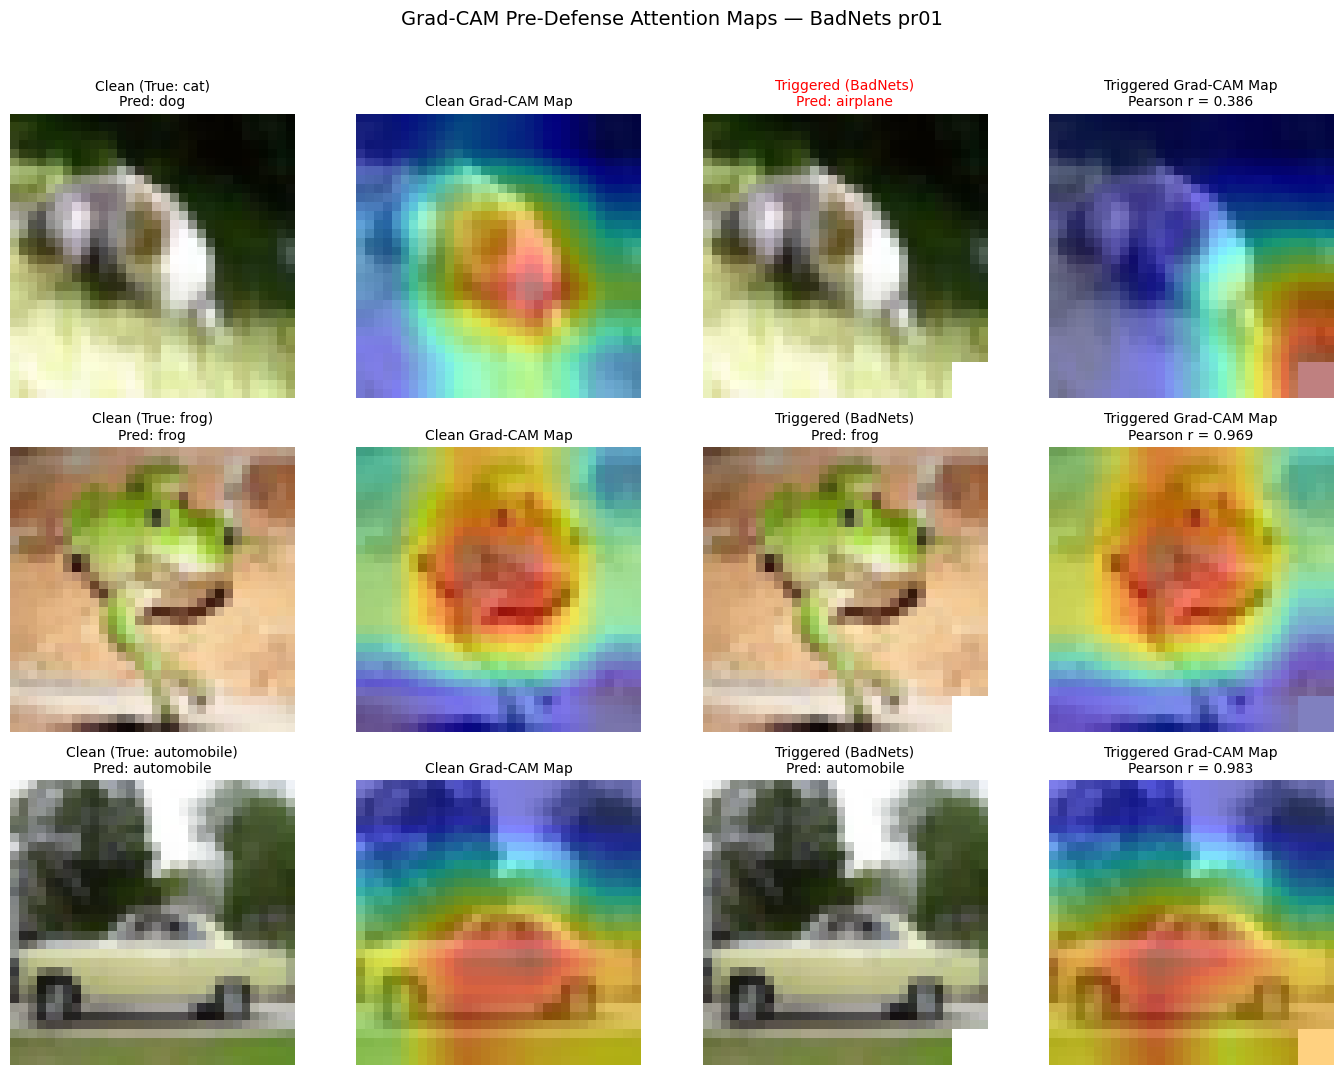


Generating Grad-CAM visualization for model: pr05
Saved visualization grid: /content/drive/MyDrive/Capstone/BadNets_Final/figures/badnets_gradcam_visual_pr05.png


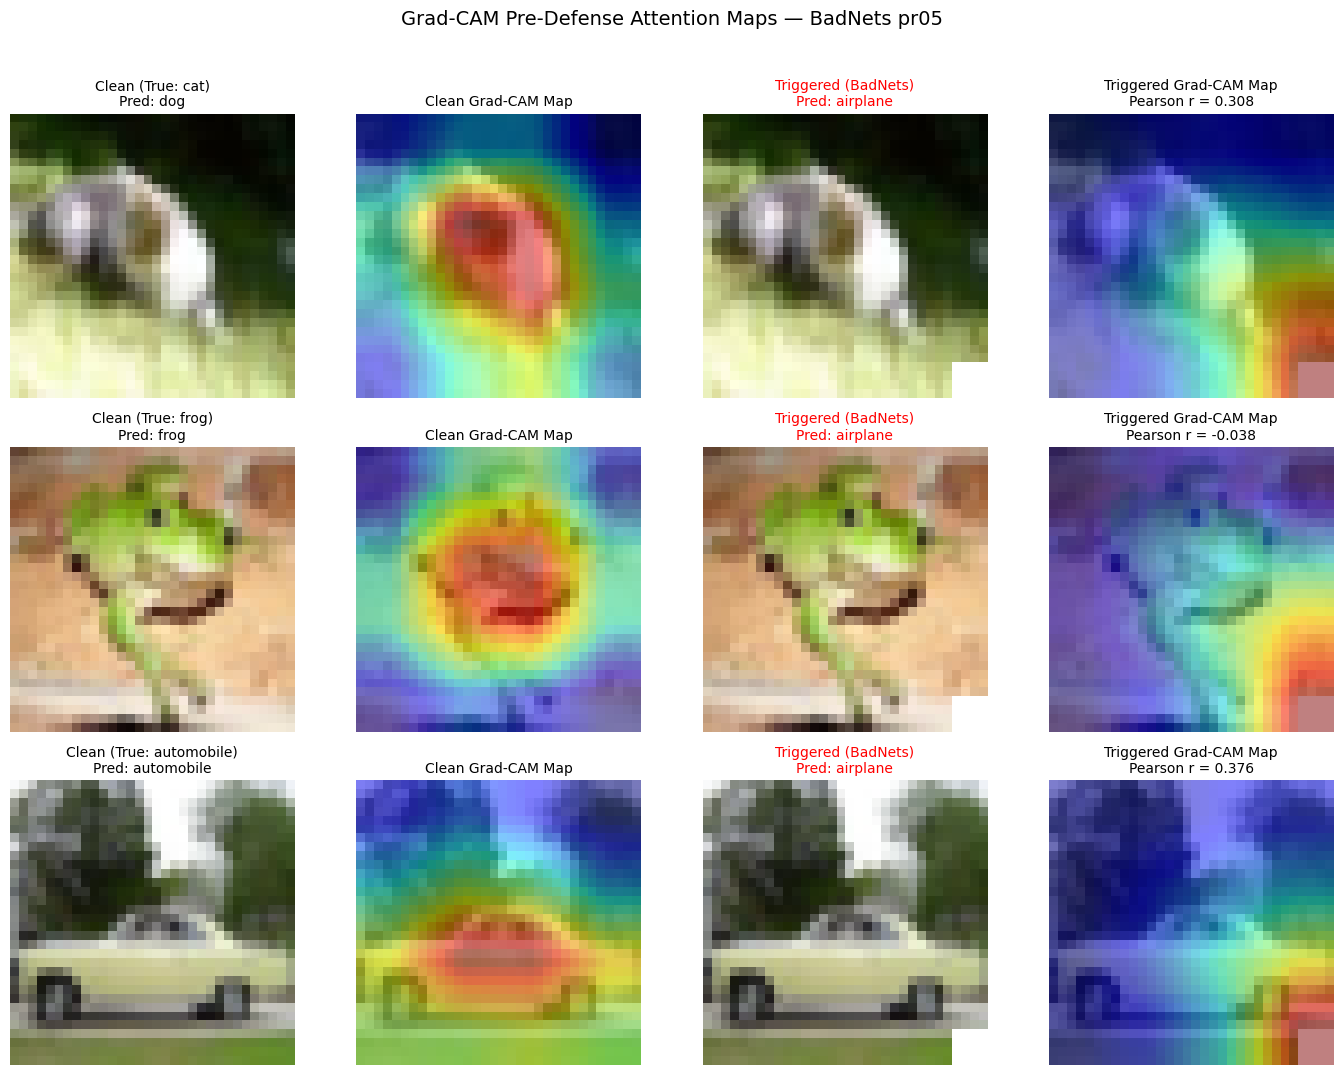


Generating Grad-CAM visualization for model: pr10
Saved visualization grid: /content/drive/MyDrive/Capstone/BadNets_Final/figures/badnets_gradcam_visual_pr10.png


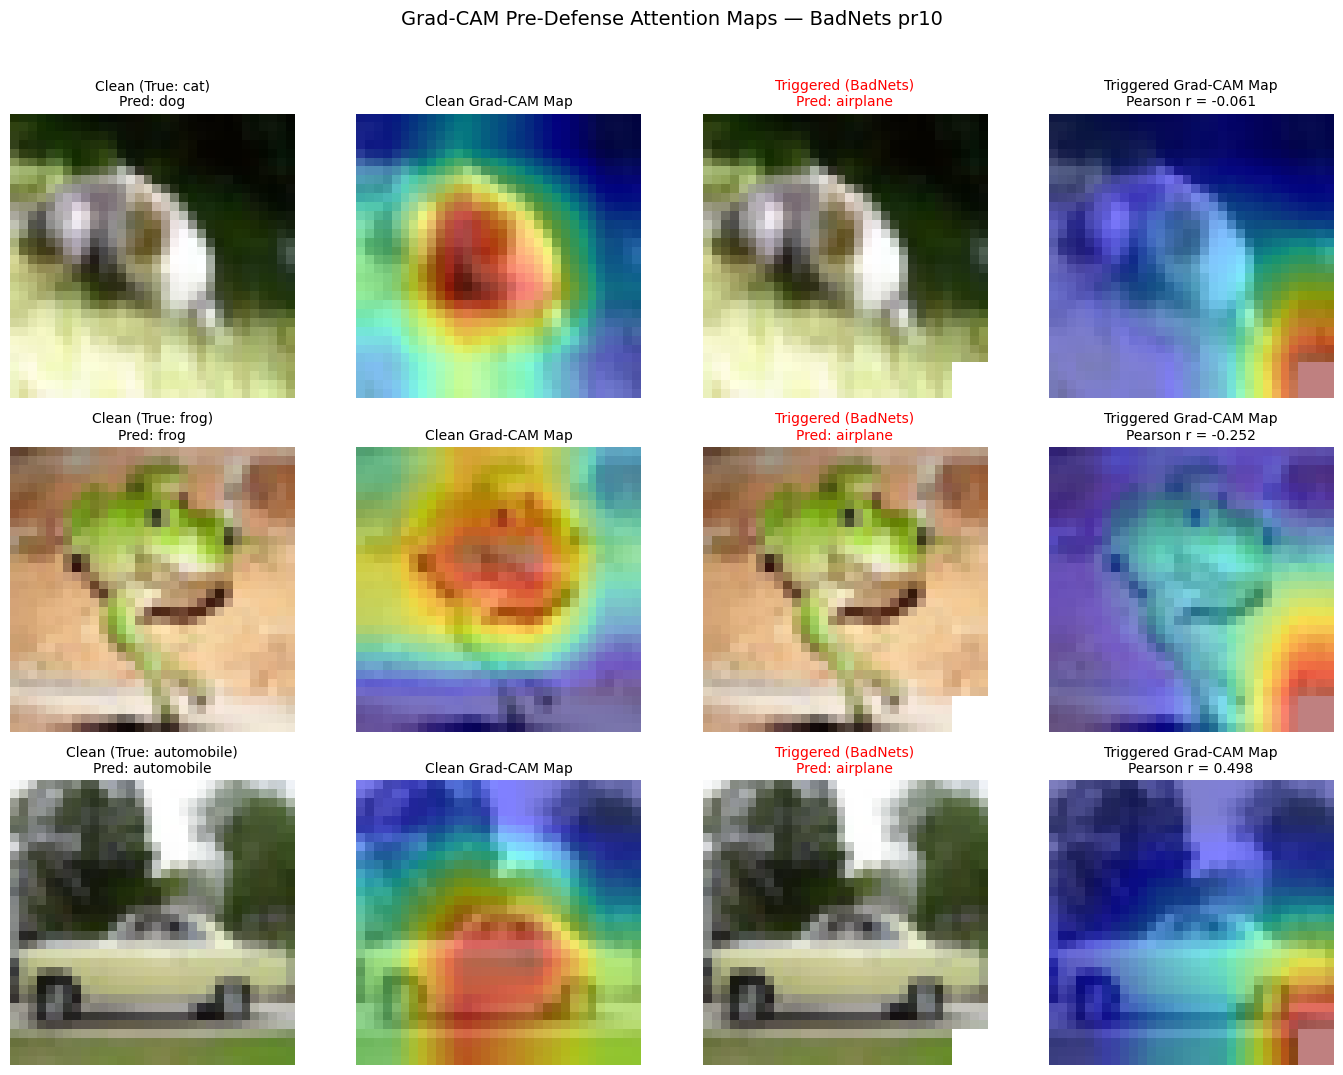

In [13]:
# ════════════════════════════════════════════════════════════════════════════
# Visual Verification: Grad-CAM Pre-Defense Heatmaps (Side-by-Side Plot)
# ════════════════════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import torch.nn.functional as F
from scipy.stats import pearsonr

CIFAR10_CLASSES   = ['airplane', 'automobile', 'bird', 'cat', 'deer',
                     'dog', 'frog', 'horse', 'ship', 'truck']
N_VISUAL_SAMPLES  = 3       # Number of test images to plot per model
GRADCAM_LAYER     = 'layer4'
TARGET_TAGS       = ['pr01', 'pr05', 'pr10']  # Main sweep checkpoints

# ── Lightweight GradCAM helper ────────────────────────────────────────────────
class GradCAM:
    def __init__(self, model, layer_name=GRADCAM_LAYER):
        self.model = model
        self.activations = None
        self.gradients = None
        layer = dict(model.named_modules())[layer_name]
        layer.register_forward_hook(self._save_activation)
        layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, inp, out):
        self.activations = out.detach()

    def _save_gradient(self, module, grad_in, grad_out):
        self.gradients = grad_out[0].detach()

    def __call__(self, x):
        self.model.zero_grad()
        out = self.model(x)
        pred_class = out.argmax(dim=1)
        score = out[0, pred_class]
        score.backward()

        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        cam = F.relu(cam)
        cam = F.interpolate(cam, size=(32, 32), mode='bilinear', align_corners=False)
        cam = cam.squeeze().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam, int(pred_class.item())

def _to_input_tensor(img_uint8):
    pil_like = img_uint8.astype(np.float32) / 255.0
    t = torch.from_numpy(pil_like).permute(2, 0, 1)
    mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3, 1, 1)
    std  = torch.tensor([0.2470, 0.2435, 0.2616]).view(3, 1, 1)
    t = (t - mean) / std
    return t.unsqueeze(0).to(DEVICE).requires_grad_(False)

# ── Sample test images ────────────────────────────────────────────────────────
_rng_vis = np.random.RandomState(SEED)
vis_sample_indices = _rng_vis.choice(asr_test_idx, size=N_VISUAL_SAMPLES, replace=False)

for _tag in TARGET_TAGS:
    _lowrate_dir = globals().get("LOWRATE_CKPT_DIR", f"{CHECKPOINT_DIR}/badnets_lowrate")
    _ckpt_path_sub  = f'{_lowrate_dir}/resnet18_badnets_{_tag}.pth'
    _ckpt_path_flat = f'{CHECKPOINT_DIR}/resnet18_badnets_{_tag}.pth'

    if os.path.exists(_ckpt_path_flat):
        _ckpt_path = _ckpt_path_flat
    elif os.path.exists(_ckpt_path_sub):
        _ckpt_path = _ckpt_path_sub
    else:
        print(f'[{_tag}] Checkpoint not found, skipping visual plot.')
        continue

    print(f'\nGenerating Grad-CAM visualization for model: {_tag}')
    _m = get_resnet18().to(DEVICE)
    _m.load_state_dict(torch.load(_ckpt_path, map_location=DEVICE))
    _m.eval()
    _cam_extractor = GradCAM(_m, GRADCAM_LAYER)

    fig, axes = plt.subplots(N_VISUAL_SAMPLES, 4, figsize=(14, 3.5 * N_VISUAL_SAMPLES))
    if N_VISUAL_SAMPLES == 1:
        axes = np.expand_dims(axes, axis=0)

    for i, _idx in enumerate(vis_sample_indices):
        _clean_img = testset_raw.data[_idx]
        _trig_img  = add_badnets_trigger(_clean_img.copy(), trigger_size=TRIGGER_SIZE)
        _gt_class  = testset_raw.targets[_idx]

        _clean_t = _to_input_tensor(_clean_img)
        _trig_t  = _to_input_tensor(_trig_img)

        _clean_cam, _clean_pred = _cam_extractor(_clean_t)
        _trig_cam,  _trig_pred  = _cam_extractor(_trig_t)

        _r, _ = pearsonr(_clean_cam.flatten(), _trig_cam.flatten())

        # 1. Clean Input Image
        axes[i, 0].imshow(_clean_img)
        axes[i, 0].set_title(f'Clean (True: {CIFAR10_CLASSES[_gt_class]})\nPred: {CIFAR10_CLASSES[_clean_pred]}', fontsize=10)
        axes[i, 0].axis('off')

        # 2. Clean Grad-CAM Overlay
        axes[i, 1].imshow(_clean_img)
        axes[i, 1].imshow(_clean_cam, cmap='jet', alpha=0.5)
        axes[i, 1].set_title('Clean Grad-CAM Map', fontsize=10)
        axes[i, 1].axis('off')

        # 3. Triggered Input Image
        axes[i, 2].imshow(_trig_img)
        is_attack_success = (_trig_pred == TARGET_CLASS)
        pred_color = 'red' if is_attack_success else 'black'
        axes[i, 2].set_title(f'Triggered (BadNets)\nPred: {CIFAR10_CLASSES[_trig_pred]}', fontsize=10, color=pred_color)
        axes[i, 2].axis('off')

        # 4. Triggered Grad-CAM Overlay
        axes[i, 3].imshow(_trig_img)
        axes[i, 3].imshow(_trig_cam, cmap='jet', alpha=0.5)
        axes[i, 3].set_title(f'Triggered Grad-CAM Map\nPearson r = {_r:.3f}', fontsize=10)
        axes[i, 3].axis('off')

    plt.suptitle(f'Grad-CAM Pre-Defense Attention Maps — BadNets {_tag}', fontsize=14, y=1.02)
    plt.tight_layout()

    _fig_save_path = f'{FIGURE_DIR}/badnets_gradcam_visual_{_tag}.png'
    plt.savefig(_fig_save_path, dpi=150, bbox_inches='tight')
    print(f'Saved visualization grid: {_fig_save_path}')
    plt.show()
